# Transformers from Scratch --- Encoder and Encoder--Decoder

Two transformers written entirely in NumPy. Every component --- token embedding, sinusoidal positional
encoding, scaled dot-product attention, multi-head attention, layer normalisation, residual connections,
the position-wise feed-forward network, causal masking and cross-attention --- is implemented explicitly,
and the backward pass through all of it is derived and coded by hand, including the gradient of the
softmax that sits inside attention.

**Part 1 --- encoder, for classification.**

```
60 tokens -> embedding (d_model) + sinusoidal positional encoding
          -> multi-head self-attention (residual + layer norm)
          -> position-wise feed-forward (residual + layer norm)
          -> mean-pool over positions -> dense -> 3 outputs -> softmax
```

**Part 2 --- encoder--decoder, for sequence-to-sequence.** The task is the reverse complement of a DNA
window: map $A\leftrightarrow T$, $C\leftrightarrow G$, then reverse the order. The output at decoder
position $t$ is the complement of the base at *source* position $L-1-t$, so the model has to learn a
long-range alignment rather than a position-by-position copy. The decoder uses masked self-attention and
cross-attention into the encoder output, is trained with teacher forcing, and is run autoregressively at
inference.

```
source -> encoder (as above, without pooling) -> memory
memory + shifted target -> masked self-attention -> cross-attention -> feed-forward -> vocabulary softmax
```

The data is the UCI *Molecular Biology (Splice-junction Gene Sequences)* set: 3190 DNA windows of
exactly 60 bases each, labelled `EI` (exon/intron boundary, a donor site), `IE` (intron/exon boundary,
an acceptor site) or `N` (neither). Every window is aligned so that the candidate junction sits between
base 30 and base 31, which gives a known ground-truth location to check the attention maps against.
Other notebooks in this repository use the same dataset and the same 80/20 seeded split; this notebook
is self-contained and imports nothing from them.

In [1]:
import time
import socket
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

BLUE   = '#2a78d6'
ORANGE = '#eb6834'
GREEN  = '#1baf7a'
GREY   = '#555555'

SEED = 42
np.random.seed(SEED)

T_LEN = 60          # sequence length in bases
JUNCTION = 30       # junction sits between base 30 and base 31 (1-based)

socket.setdefaulttimeout(60)

T_START = time.time()

## Loading and encoding the data

`fetch_ucirepo(id=69)` returns one column per base position (`Base1` .. `Base60`), each holding a single
character. The raw values carry leading whitespace, so every cell is stripped first. The alphabet is
dominated by `A`, `C`, `G`, `T`; a handful of ambiguity codes (`N`, `D`, `R`, `S`) are folded into a
single `UNK` symbol. That gives a vocabulary of 5 and an integer matrix `X_idx` of shape (3190, 60),
which is what the embedding table will be indexed with.

In [2]:
splice = None
for attempt in range(5):                 # the UCI endpoint occasionally stalls
    try:
        splice = fetch_ucirepo(id=69)
        break
    except Exception:
        if attempt == 4:
            raise
        time.sleep(5)

raw_X = splice.data.features
raw_y = splice.data.targets.iloc[:, 0]

# strip whitespace from every cell
chars = np.char.strip(raw_X.values.astype(str))
labels = np.char.strip(raw_y.values.astype(str))

VOCAB = ['A', 'C', 'G', 'T', 'UNK']
char_to_idx = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
X_idx = np.array([[char_to_idx.get(c, 4) for c in row] for row in chars], dtype=np.int64)

CLASSES = ['EI', 'IE', 'N']
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
y_all = np.array([class_to_idx[l] for l in labels], dtype=np.int64)

vals, cnts = np.unique(chars, return_counts=True)
print('raw symbol counts:', dict(zip(vals, cnts)))
print('vocabulary       :', VOCAB)
print('X_idx shape      :', X_idx.shape, X_idx.dtype)
print('UNK cells        :', int((X_idx == 4).sum()))

cls_counts = np.array([(y_all == i).sum() for i in range(3)])
print('class counts     :', dict(zip(CLASSES, cls_counts)))
BASELINE = cls_counts.max() / len(y_all)
print('majority baseline: %.4f' % BASELINE)

raw symbol counts: {'A': 44487, 'C': 50300, 'D': 2, 'G': 50245, 'N': 56, 'R': 1, 'S': 1, 'T': 46308}
vocabulary       : ['A', 'C', 'G', 'T', 'UNK']
X_idx shape      : (3190, 60) int64
UNK cells        : 60
class counts     : {'EI': 767, 'IE': 768, 'N': 1655}
majority baseline: 0.5188


## Train/test split

A single seeded permutation of the 3190 rows, cut 80/20. The same split indices are reused in Part 2, so
no source sequence appears on both sides of the boundary in either task.

In [3]:
rng_split = np.random.RandomState(SEED)
perm = rng_split.permutation(len(X_idx))
n_train = int(0.8 * len(X_idx))

train_i, test_i = perm[:n_train], perm[n_train:]
X_train, y_train = X_idx[train_i], y_all[train_i]
X_test,  y_test  = X_idx[test_i],  y_all[test_i]

print('train:', X_train.shape, 'test:', X_test.shape)
for i, c in enumerate(CLASSES):
    print('  %-3s train %4d   test %4d' % (c, (y_train == i).sum(), (y_test == i).sum()))

train: (2552, 60) test: (638, 60)
  EI  train  627   test  140
  IE  train  601   test  167
  N   train 1324   test  331


### Figure 1 --- class balance and per-position base composition

The left panel is the class histogram; `N` is the majority class at 51.9%, which is the accuracy floor
any model has to beat. The right panel plots, for each of the 60 positions, the frequency of each base
across the whole dataset. The composition is close to uniform far from the junction and swings sharply
right at the junction, which is the signal the model has to find.

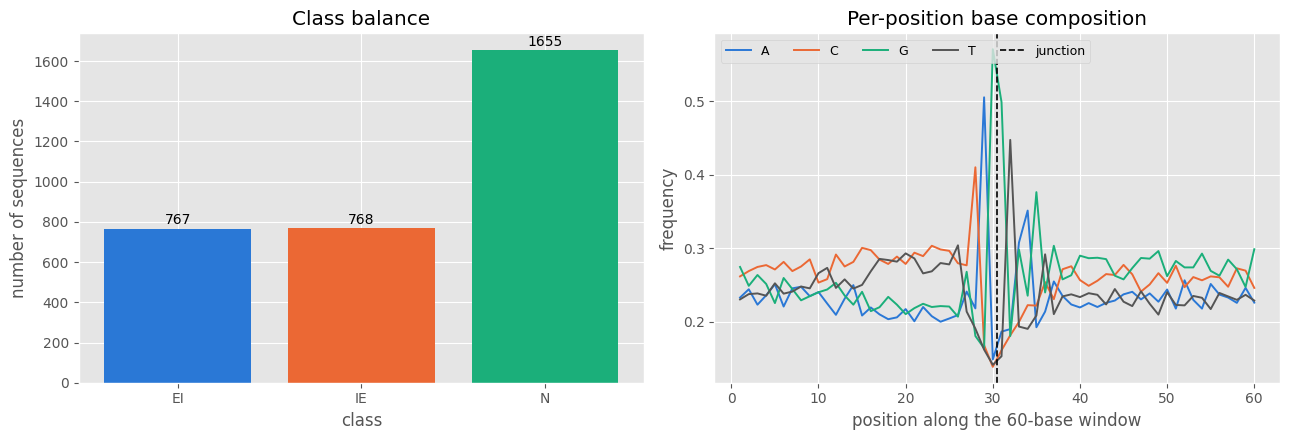

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(CLASSES, cls_counts, color=[BLUE, ORANGE, GREEN])
for i, v in enumerate(cls_counts):
    ax[0].text(i, v + 20, str(v), ha='center', fontsize=10)
ax[0].set_title('Class balance')
ax[0].set_xlabel('class')
ax[0].set_ylabel('number of sequences')

positions = np.arange(1, T_LEN + 1)
base_cols = [BLUE, ORANGE, GREEN, GREY]
for b in range(4):
    freq = (X_idx == b).mean(axis=0)
    ax[1].plot(positions, freq, color=base_cols[b], linewidth=1.4, label=VOCAB[b])
ax[1].axvline(JUNCTION + 0.5, color='k', linestyle='--', linewidth=1.2, label='junction')
ax[1].set_title('Per-position base composition')
ax[1].set_xlabel('position along the 60-base window')
ax[1].set_ylabel('frequency')
ax[1].legend(loc='upper left', ncol=5, fontsize=9)

plt.tight_layout()
plt.show()

## Positional encoding

Self-attention has no notion of order. The output at position $i$ is a weighted sum of value vectors
over all positions, and the weights depend only on the *content* of the vectors, not on where they sit.
Permuting the input rows therefore permutes the output rows and changes nothing else --- attention is
permutation-equivariant. Follow that with a mean-pool and the whole model becomes permutation
*invariant*: it would see an unordered bag of bases and could not possibly say where a splice site is.

Position has to be injected into the representation itself. The fixed sinusoidal scheme adds, to the
embedding at position $pos$, a vector whose $2i$-th and $(2i{+}1)$-th entries are

$$PE_{(pos,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \qquad
  PE_{(pos,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

Each pair of dimensions is a sine/cosine at its own frequency, geometrically spaced from wavelength
$2\pi$ up to $10000 \cdot 2\pi$. Low dimensions oscillate fast and distinguish neighbouring positions;
high dimensions oscillate slowly and encode coarse location in the window. Because it is a fixed
function of $pos$ rather than a learned table, it needs no parameters and extends to lengths never seen
in training.

A property that matters for Part 2: a shift or reflection of position is a *linear* map on each
sine/cosine pair, since $\sin(c - pos\,\omega) = \sin(c\,\omega)\cos(pos\,\omega) - \cos(c\,\omega)\sin(pos\,\omega)$.
A single linear query projection can therefore turn "where I am" into "the position I should read from",
which is exactly what the reverse-complement alignment needs.

`positional_encoding(T, d)` below builds the $(T, d)$ matrix, and it is added to the token embeddings
before the encoder block.

In [5]:
def positional_encoding(T, d):
    pos = np.arange(T)[:, None].astype(np.float64)
    i = np.arange(d // 2)[None, :].astype(np.float64)
    ang = pos / np.power(10000.0, (2.0 * i) / d)
    pe = np.zeros((T, d))
    pe[:, 0::2] = np.sin(ang)
    pe[:, 1::2] = np.cos(ang)
    return pe


D_MODEL = 32
PE_DEMO = positional_encoding(T_LEN, D_MODEL)
print('PE shape:', PE_DEMO.shape, ' range: [%.3f, %.3f]' % (PE_DEMO.min(), PE_DEMO.max()))

PE shape: (60, 32)  range: [-1.000, 1.000]


### Figure 2 --- the positional encoding matrix

Position on the vertical axis, embedding dimension on the horizontal. The stripes are the sine/cosine
pairs: on the left the frequency is high and the pattern alternates every row or two, and moving right
the wavelength stretches until the last columns barely change over the whole 60 positions. Reading a
single row gives a code that is unique to that position; reading a single column gives one oscillator.

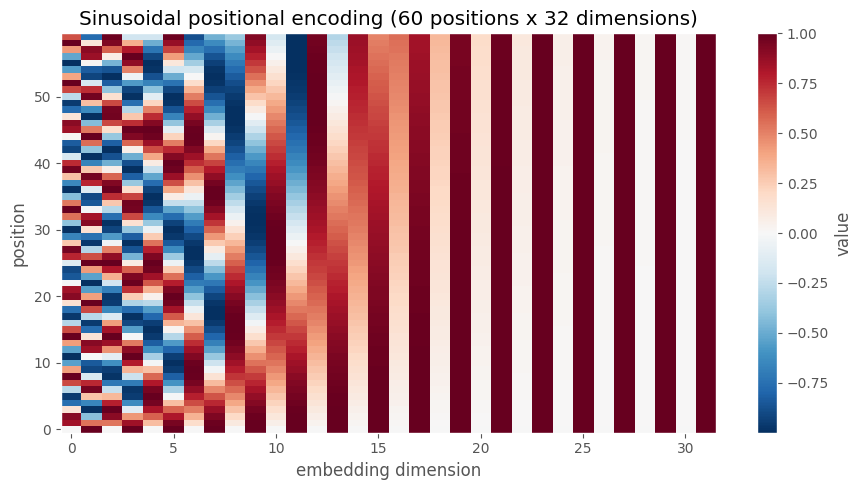

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(PE_DEMO, aspect='auto', cmap='RdBu_r', origin='lower')
ax.set_title('Sinusoidal positional encoding (60 positions x 32 dimensions)')
ax.set_xlabel('embedding dimension')
ax.set_ylabel('position')
ax.grid(False)
cb = fig.colorbar(im, ax=ax)
cb.set_label('value')
plt.tight_layout()
plt.show()

## Scaled dot-product attention

The core operation. From the input $X \in \mathbb{R}^{T \times d}$ three linear projections are formed,
$Q = XW_Q$, $K = XW_K$, $V = XW_V$, and then

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Piece by piece:

* $QK^\top$ is a $T \times T$ matrix in which entry $(i,j)$ is the dot product of the query at position
  $i$ with the key at position $j$ --- every position scoring every other position for relevance.
* The softmax is taken along each row, turning row $i$ into a set of non-negative weights summing to 1:
  a distribution over which positions $i$ should read from.
* Multiplying by $V$ replaces the vector at position $i$ with the weighted average of the value vectors
  at all positions, weighted by that distribution. Information moves from anywhere to anywhere in one
  matrix product.

**Why the $\sqrt{d_k}$.** Take $Q$ and $K$ entries to be independent with mean 0 and unit variance. A
single logit is a sum of $d_k$ products of such entries, so it has mean 0 and variance $d_k$; its
typical magnitude grows like $\sqrt{d_k}$. Feed logits of that size into a softmax and the largest one
dominates, the distribution collapses onto one position, and the softmax Jacobian
$\text{diag}(a) - aa^\top$ goes to zero --- the gradient vanishes and training stalls. Dividing by
$\sqrt{d_k}$ restores unit variance to the logits regardless of head width, keeping the softmax in a
region where it still has gradient.

## Multi-head attention

$$\text{MultiHead}(X) = \left[\text{head}_1;\dots;\text{head}_h\right]W_O, \qquad
  \text{head}_i = \text{Attention}(XW_Q^i, XW_K^i, XW_V^i)$$

Instead of one attention over all $d$ dimensions, $d$ is split into $h$ heads of width
$d_k = d/h$, attention is computed independently in each, the $h$ outputs are concatenated back to
width $d$ and mixed by $W_O$. A single softmax produces one distribution per position, so one head can
only average over one relationship at a time --- averaging two different things gives a blur of both.
Several narrow heads produce several distributions at once, so one head can track the base immediately
upstream while another tracks a motif thirty positions away. The cost is unchanged, because the heads
are narrower in exact proportion to their number.

### Permutation equivariance, demonstrated

The cell below builds a random input, runs raw self-attention on it, then runs the same attention on a
row-permuted copy. The outputs are identical up to the same permutation, to machine precision. That is
the formal statement that attention alone cannot know where anything is.

In [7]:
def softmax(z, axis=-1):
    z = z - z.max(axis=axis, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=axis, keepdims=True)


def self_attention(X, Wq, Wk, Wv):
    # single-head scaled dot-product attention on a (T, d) input
    dk = X.shape[1]
    Q, K, V = X @ Wq, X @ Wk, X @ Wv
    A = softmax((Q @ K.T) / np.sqrt(dk), axis=-1)
    return A @ V


rng_demo = np.random.RandomState(0)
Xd = rng_demo.normal(size=(8, 6))
Wq_d = rng_demo.normal(size=(6, 6)) * 0.3
Wk_d = rng_demo.normal(size=(6, 6)) * 0.3
Wv_d = rng_demo.normal(size=(6, 6)) * 0.3

out = self_attention(Xd, Wq_d, Wk_d, Wv_d)
p = rng_demo.permutation(8)
out_perm = self_attention(Xd[p], Wq_d, Wk_d, Wv_d)

print('permutation          :', p)
print('max |f(PX) - P f(X)| : %.3e' % np.abs(out_perm - out[p]).max())
print('attention is permutation-equivariant, so position must be added to the input itself')

permutation          : [0 7 1 5 3 4 2 6]
max |f(PX) - P f(X)| : 6.661e-16
attention is permutation-equivariant, so position must be added to the input itself


## Layer normalisation and residual connections

$$\text{LN}(\mathbf{x}) = \gamma \odot \frac{\mathbf{x} - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

The mean $\mu$ and variance $\sigma^2$ are taken over the $d$ feature entries of a *single* position's
vector, and $\gamma, \beta \in \mathbb{R}^{d}$ are learned. This is the contrast with batch norm, which
normalises each feature over the batch dimension: batch norm's statistics depend on which other
examples happen to share the batch and need a separate running estimate at test time, whereas layer
norm treats every position independently, behaves identically for a batch of 1 or 1000, and needs no
train/test distinction. It keeps activations at a consistent scale entering each sub-layer, which is
what stops the residual stream from drifting.

The **residual connections** wrap each sub-layer: the block computes $\text{LN}(x + \text{Sublayer}(x))$
rather than $\text{LN}(\text{Sublayer}(x))$. The addition gives the gradient a path straight back to the
embeddings that does not pass through the sub-layer's weights, so the sub-layer only has to learn a
correction to the identity rather than a whole useful transformation from scratch.

`layer_norm` returns the normalised output plus the cache its backward pass needs.
`layer_norm_backward` implements

$$\frac{\partial L}{\partial x} = \frac{1}{\sqrt{\sigma^2+\epsilon}}
  \left(\hat{g} - \overline{\hat{g}} - \hat{x}\,\overline{\hat{g}\hat{x}}\right),
  \qquad \hat{g} = \frac{\partial L}{\partial y}\odot\gamma$$

where the bars are means over the feature axis --- the two subtracted terms are what account for $\mu$
and $\sigma$ themselves depending on $x$.

In [8]:
LN_EPS = 1e-5

def layer_norm(x, gamma, beta):
    mu = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    std = np.sqrt(var + LN_EPS)
    xhat = (x - mu) / std
    return gamma * xhat + beta, (xhat, std, gamma)


def layer_norm_backward(dy, cache):
    xhat, std, gamma = cache
    dgamma = (dy * xhat).sum(axis=(0, 1))
    dbeta = dy.sum(axis=(0, 1))
    dxhat = dy * gamma
    m1 = dxhat.mean(axis=-1, keepdims=True)
    m2 = (dxhat * xhat).mean(axis=-1, keepdims=True)
    dx = (dxhat - m1 - xhat * m2) / std
    return dx, dgamma, dbeta

## The encoder

`Transformer` holds every weight as a plain attribute and lists their names in `self.params`, which is
what the optimiser iterates over.

`forward` runs, for a batch of integer sequences `Xi` of shape (B, 60):

1. `E = Wemb[Xi]` --- the embedding lookup, (B, 60, d).
2. `H0 = E + PE` --- positional encoding added (skipped when `use_pos` is False, which is the ablation).
3. `Q, K, V = H0 @ Wq, H0 @ Wk, H0 @ Wv`, each reshaped to (B, h, 60, d_k) so the heads attend
   independently.
4. `scores = Q Kt / sqrt(d_k)`, `A = softmax(scores)`, `Ctx = A @ V`; heads concatenated back to width
   `d` and projected by `Wo`.
5. `H1 = LN1(H0 + attn)` --- residual then layer norm.
6. `Z1 = H1 @ W1 + b1`, `Aff = relu(Z1)`, `Z2 = Aff @ W2 + b2` --- the position-wise feed-forward,
   applied to each position separately with the same weights, widening to `d_ff` and back.
7. `H2 = LN2(H1 + Z2)`.
8. Mean-pool over the 60 positions, one dense layer to 3 logits, softmax.

`backward` walks that in reverse. The two pieces worth naming: the mean-pool sends `dpool / T` to every
position, and the softmax inside attention contributes

$$\frac{\partial L}{\partial s_{ij}} = a_{ij}\left(\frac{\partial L}{\partial a_{ij}}
  - \sum_{k} \frac{\partial L}{\partial a_{ik}} a_{ik}\right)$$

which is the row-wise softmax Jacobian $\text{diag}(a)-aa^\top$ applied without ever forming it. The
embedding gradient is a scatter-add, since the same vocabulary row is read at many positions.

Everything is written out inline here so each step is visible. Part 2 factors the same algebra into
reusable `mha_forward` / `mha_backward` functions, because it needs three attention blocks.

In [9]:
class Transformer:

    def __init__(self, vocab, seq_len, d_model=32, n_heads=4, d_ff=64,
                 n_classes=3, use_pos=True, seed=1):
        rng = np.random.RandomState(seed)
        self.V = vocab
        self.T = seq_len
        self.d = d_model
        self.h = n_heads
        self.dk = d_model // n_heads
        self.d_ff = d_ff
        self.C = n_classes
        self.use_pos = use_pos

        s = 1.0 / np.sqrt(d_model)
        self.Wemb = rng.normal(0, s, (vocab, d_model))
        self.PE = positional_encoding(seq_len, d_model)

        self.Wq = rng.normal(0, s, (d_model, d_model))
        self.Wk = rng.normal(0, s, (d_model, d_model))
        self.Wv = rng.normal(0, s, (d_model, d_model))
        self.Wo = rng.normal(0, s, (d_model, d_model))
        self.bo = np.zeros(d_model)

        self.g1 = np.ones(d_model)
        self.bn1 = np.zeros(d_model)

        self.W1 = rng.normal(0, 1.0 / np.sqrt(d_model), (d_model, d_ff))
        self.b1 = np.zeros(d_ff)
        self.W2 = rng.normal(0, 1.0 / np.sqrt(d_ff), (d_ff, d_model))
        self.b2 = np.zeros(d_model)

        self.g2 = np.ones(d_model)
        self.bn2 = np.zeros(d_model)

        self.Wc = rng.normal(0, 1.0 / np.sqrt(d_model), (d_model, n_classes))
        self.bc = np.zeros(n_classes)

        self.params = ['Wemb', 'Wq', 'Wk', 'Wv', 'Wo', 'bo', 'g1', 'bn1',
                       'W1', 'b1', 'W2', 'b2', 'g2', 'bn2', 'Wc', 'bc']

    def _split(self, x):
        B, T, _ = x.shape
        return x.reshape(B, T, self.h, self.dk).transpose(0, 2, 1, 3)

    def _merge(self, x):
        B, h, T, dk = x.shape
        return x.transpose(0, 2, 1, 3).reshape(B, T, h * dk)

    def forward(self, Xi):
        B, T = Xi.shape
        E = self.Wemb[Xi]
        H0 = E + self.PE[None, :, :] if self.use_pos else E

        Q = H0 @ self.Wq
        K = H0 @ self.Wk
        Vv = H0 @ self.Wv
        Qh, Kh, Vh = self._split(Q), self._split(K), self._split(Vv)

        scores = (Qh @ Kh.transpose(0, 1, 3, 2)) / np.sqrt(self.dk)
        A = softmax(scores, axis=-1)
        Ctx = A @ Vh
        Cm = self._merge(Ctx)
        attn = Cm @ self.Wo + self.bo

        H1, ln1 = layer_norm(H0 + attn, self.g1, self.bn1)

        Z1 = H1 @ self.W1 + self.b1
        Aff = np.maximum(Z1, 0.0)
        Z2 = Aff @ self.W2 + self.b2

        H2, ln2 = layer_norm(H1 + Z2, self.g2, self.bn2)

        pool = H2.mean(axis=1)
        logits = pool @ self.Wc + self.bc
        P = softmax(logits, axis=-1)

        self.cache = (Xi, H0, Qh, Kh, Vh, A, Cm, ln1, H1, Z1, Aff, ln2, pool, P)
        self.A = A
        return P

    def loss(self, y):
        P = self.cache[-1]
        return -np.log(P[np.arange(len(y)), y] + 1e-12).mean()

    def backward(self, y):
        Xi, H0, Qh, Kh, Vh, A, Cm, ln1, H1, Z1, Aff, ln2, pool, P = self.cache
        B, T = Xi.shape
        d, h, dk = self.d, self.h, self.dk

        Y = np.zeros_like(P)
        Y[np.arange(len(y)), y] = 1.0
        dlogits = (P - Y) / B

        g = {}
        g['Wc'] = pool.T @ dlogits
        g['bc'] = dlogits.sum(axis=0)
        dpool = dlogits @ self.Wc.T

        # mean over positions spreads the gradient evenly
        dH2 = np.repeat(dpool[:, None, :], T, axis=1) / T

        dR2, g['g2'], g['bn2'] = layer_norm_backward(dH2, ln2)
        dH1 = dR2.copy()

        dZ2 = dR2
        g['W2'] = Aff.reshape(-1, self.d_ff).T @ dZ2.reshape(-1, d)
        g['b2'] = dZ2.sum(axis=(0, 1))
        dAff = dZ2 @ self.W2.T
        dZ1 = dAff * (Z1 > 0)
        g['W1'] = H1.reshape(-1, d).T @ dZ1.reshape(-1, self.d_ff)
        g['b1'] = dZ1.sum(axis=(0, 1))
        dH1 += dZ1 @ self.W1.T

        dR1, g['g1'], g['bn1'] = layer_norm_backward(dH1, ln1)
        dH0 = dR1.copy()

        dattn = dR1
        g['Wo'] = Cm.reshape(-1, d).T @ dattn.reshape(-1, d)
        g['bo'] = dattn.sum(axis=(0, 1))
        dCm = dattn @ self.Wo.T
        dCtx = self._split(dCm)

        # through Ctx = A @ Vh
        dA = dCtx @ Vh.transpose(0, 1, 3, 2)
        dVh = A.transpose(0, 1, 3, 2) @ dCtx

        # row-wise softmax Jacobian, never formed explicitly
        dscores = A * (dA - (dA * A).sum(axis=-1, keepdims=True))
        dscores = dscores / np.sqrt(dk)

        dQh = dscores @ Kh
        dKh = dscores.transpose(0, 1, 3, 2) @ Qh

        dQ, dK, dV = self._merge(dQh), self._merge(dKh), self._merge(dVh)
        Hf = H0.reshape(-1, d)
        g['Wq'] = Hf.T @ dQ.reshape(-1, d)
        g['Wk'] = Hf.T @ dK.reshape(-1, d)
        g['Wv'] = Hf.T @ dV.reshape(-1, d)
        dH0 += dQ @ self.Wq.T + dK @ self.Wk.T + dV @ self.Wv.T

        dWemb = np.zeros_like(self.Wemb)
        np.add.at(dWemb, Xi.ravel(), dH0.reshape(-1, d))
        g['Wemb'] = dWemb
        return g

    def predict(self, Xi, chunk=256):
        out = []
        for s in range(0, len(Xi), chunk):
            out.append(self.forward(Xi[s:s + chunk]))
        return np.vstack(out)

## Finite-difference gradient check --- encoder

The analytic gradients are compared against central differences,

$$\frac{\partial L}{\partial w} \approx \frac{L(w+\varepsilon) - L(w-\varepsilon)}{2\varepsilon},
  \qquad \varepsilon = 10^{-5}$$

on a fixed batch of 12 sequences. For each of the eight weight tensors checked --- including `Wq`, `Wk`
and `Wv` inside the attention projections and `Wemb` in the embedding table --- the entry with the
largest analytic gradient is chosen, so the comparison is made where the signal is strongest rather
than in the numerical noise. For the embedding only rows that actually appear in the batch are
eligible.

This is the check that matters. Backpropagating through the softmax *inside* attention is the easiest
step to get subtly wrong --- dropping the $-a\sum(\cdot\, a)$ term, or applying the $1/\sqrt{d_k}$ on
the wrong side --- and such an error still trains, just worse. Nothing else in this notebook would
reveal it. The same check is repeated for the encoder--decoder in Part 2, where it also covers the
causal mask and the cross-attention projections.

In [10]:
gc_model = Transformer(len(VOCAB), T_LEN, d_model=D_MODEL, n_heads=4, d_ff=64, seed=7)
Xg, yg = X_train[:12], y_train[:12]

gc_model.forward(Xg)
grads = gc_model.backward(yg)

EPS = 1e-5

def num_grad(name, index):
    W = getattr(gc_model, name)
    orig = W[index]
    W[index] = orig + EPS
    gc_model.forward(Xg)
    lp = gc_model.loss(yg)
    W[index] = orig - EPS
    gc_model.forward(Xg)
    lm = gc_model.loss(yg)
    W[index] = orig
    return (lp - lm) / (2.0 * EPS)


used_rows = np.unique(Xg)
checks = []
for name in ['Wemb', 'Wq', 'Wk', 'Wv', 'Wo', 'W1', 'W2', 'Wc']:
    G = grads[name]
    if name == 'Wemb':
        mask = np.zeros_like(G, dtype=bool)
        mask[used_rows] = True
        G = np.where(mask, np.abs(G), -1.0)
        idx = np.unravel_index(np.argmax(G), G.shape)
    else:
        idx = np.unravel_index(np.argmax(np.abs(G)), G.shape)
    checks.append((name, idx))

print('%-6s %-10s %18s %18s %14s' % ('param', 'index', 'analytic', 'numerical', 'abs diff'))
print('-' * 72)
worst = 0.0
for name, idx in checks:
    a = grads[name][idx]
    n = num_grad(name, idx)
    worst = max(worst, abs(a - n))
    print('%-6s %-10s %18.12f %18.12f %14.2e' % (name, str(idx), a, n, abs(a - n)))
print('-' * 72)
print('largest absolute disagreement: %.2e' % worst)
assert worst < 1e-8, 'gradient check failed'
print('gradient check passed (agreement to at least 8 decimal places)')

param  index                analytic          numerical       abs diff
------------------------------------------------------------------------
Wemb   (1, 11)       -0.045293321926    -0.045293321926       4.21e-13
Wq     (31, 0)        0.004432034494     0.004432034484       9.87e-12
Wk     (4, 13)       -0.007374690358    -0.007374690358       7.65e-13
Wv     (23, 22)      -0.079399238112    -0.079399238107       5.46e-12
Wo     (21, 11)      -0.091272709515    -0.091272709513       1.93e-12
W1     (7, 0)         0.081600120652     0.081600120638       1.33e-11
W2     (41, 30)      -0.156792262708    -0.156792262729       2.07e-11


Wc     (7, 2)        -0.414865953150    -0.414865953158       7.91e-12
------------------------------------------------------------------------
largest absolute disagreement: 2.07e-11
gradient check passed (agreement to at least 8 decimal places)


## Training the encoder

Adam with the usual $\beta_1=0.9$, $\beta_2=0.999$, mini-batches of 64, 60 epochs, learning rate
$2\times10^{-3}$. The optimiser state lives in `adam_state` and the update is written out directly;
`train_model` records train and test loss and accuracy after every epoch.

In [11]:
def evaluate(model, X, y, chunk=256):
    tot, correct = 0.0, 0
    for s in range(0, len(X), chunk):
        P = model.forward(X[s:s + chunk])
        yy = y[s:s + chunk]
        tot += -np.log(P[np.arange(len(yy)), yy] + 1e-12).sum()
        correct += int((P.argmax(axis=1) == yy).sum())
    return tot / len(X), correct / len(X)


def train_model(model, Xtr, ytr, Xte, yte, epochs=60, batch=64, lr=2e-3, seed=0, log_every=10):
    rng = np.random.RandomState(seed)
    adam_state = {k: [np.zeros_like(getattr(model, k)), np.zeros_like(getattr(model, k))]
                  for k in model.params}
    b1, b2, eps = 0.9, 0.999, 1e-8
    step = 0
    hist = {'tr_loss': [], 'te_loss': [], 'tr_acc': [], 'te_acc': []}
    n = len(Xtr)

    for ep in range(1, epochs + 1):
        order = rng.permutation(n)
        for s in range(0, n, batch):
            idx = order[s:s + batch]
            model.forward(Xtr[idx])
            g = model.backward(ytr[idx])
            step += 1
            for k in model.params:
                m, v = adam_state[k]
                m *= b1
                m += (1 - b1) * g[k]
                v *= b2
                v += (1 - b2) * (g[k] ** 2)
                mh = m / (1 - b1 ** step)
                vh = v / (1 - b2 ** step)
                setattr(model, k, getattr(model, k) - lr * mh / (np.sqrt(vh) + eps))

        trl, tra = evaluate(model, Xtr, ytr)
        tel, tea = evaluate(model, Xte, yte)
        hist['tr_loss'].append(trl)
        hist['te_loss'].append(tel)
        hist['tr_acc'].append(tra)
        hist['te_acc'].append(tea)
        if ep % log_every == 0 or ep == 1:
            print('epoch %3d   train loss %.4f acc %.4f   test loss %.4f acc %.4f'
                  % (ep, trl, tra, tel, tea))
    return hist


EPOCHS = 60
t0 = time.time()
model = Transformer(len(VOCAB), T_LEN, d_model=D_MODEL, n_heads=4, d_ff=64,
                    use_pos=True, seed=1)
hist = train_model(model, X_train, y_train, X_test, y_test, epochs=EPOCHS, seed=SEED)
t_main = time.time() - t0
print('\ntraining time (with positional encoding): %.1f s' % t_main)

epoch   1   train loss 1.0012 acc 0.5188   test loss 0.9982 acc 0.5188


epoch  10   train loss 0.1923 acc 0.9397   test loss 0.1945 acc 0.9342


epoch  20   train loss 0.2414 acc 0.9126   test loss 0.2830 acc 0.8997


epoch  30   train loss 0.1189 acc 0.9596   test loss 0.1463 acc 0.9483


epoch  40   train loss 0.1428 acc 0.9483   test loss 0.1823 acc 0.9373


epoch  50   train loss 0.0940 acc 0.9687   test loss 0.1452 acc 0.9483


epoch  60   train loss 0.0859 acc 0.9706   test loss 0.1437 acc 0.9545

training time (with positional encoding): 157.8 s


### Figure 3 --- learning curves

Cross-entropy and accuracy per epoch on both splits. The gap that opens between the train and test
curves is the model memorising 2552 sequences with roughly 12k parameters; the dashed line on the right
is the 0.519 majority-class baseline.

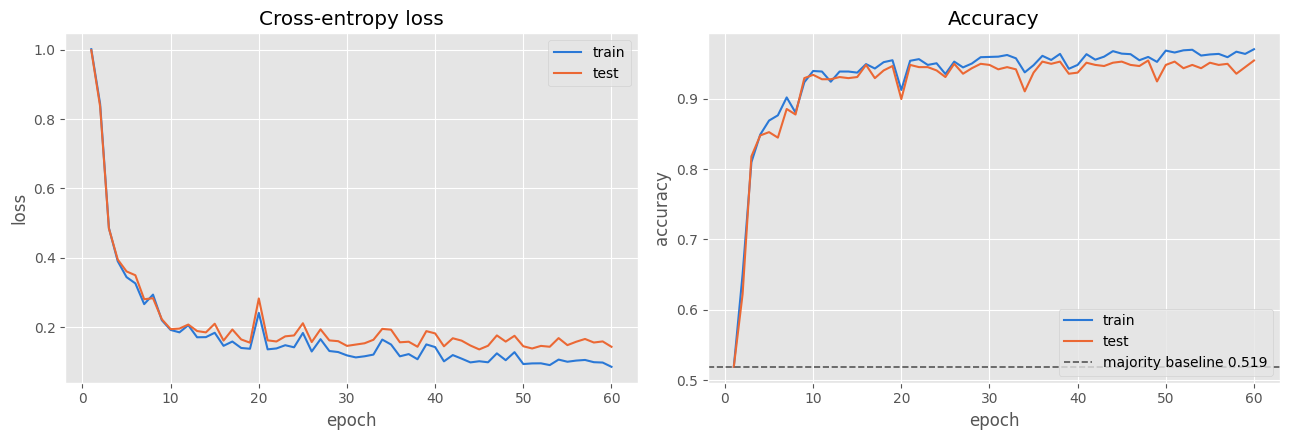

final test accuracy: 0.9545   baseline: 0.5188
best  test accuracy: 0.9545  (epoch 48)


In [12]:
ep_axis = np.arange(1, EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(ep_axis, hist['tr_loss'], color=BLUE, label='train')
ax[0].plot(ep_axis, hist['te_loss'], color=ORANGE, label='test')
ax[0].set_title('Cross-entropy loss')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].legend()

ax[1].plot(ep_axis, hist['tr_acc'], color=BLUE, label='train')
ax[1].plot(ep_axis, hist['te_acc'], color=ORANGE, label='test')
ax[1].axhline(BASELINE, color=GREY, linestyle='--', linewidth=1.2,
              label='majority baseline %.3f' % BASELINE)
ax[1].set_title('Accuracy')
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print('final test accuracy: %.4f   baseline: %.4f' % (hist['te_acc'][-1], BASELINE))
print('best  test accuracy: %.4f  (epoch %d)' % (max(hist['te_acc']), int(np.argmax(hist['te_acc'])) + 1))

### Figure 4 --- attention weight matrices

For two test sequences, the full 60x60 attention matrix of every head. Row $i$ is the distribution over
which positions the vector at position $i$ reads from, so each row sums to 1. Vertical bands mean a
position is read by everything; a bright diagonal means each position mostly attends to itself or its
neighbours. The dashed cross marks the junction at 30/31.

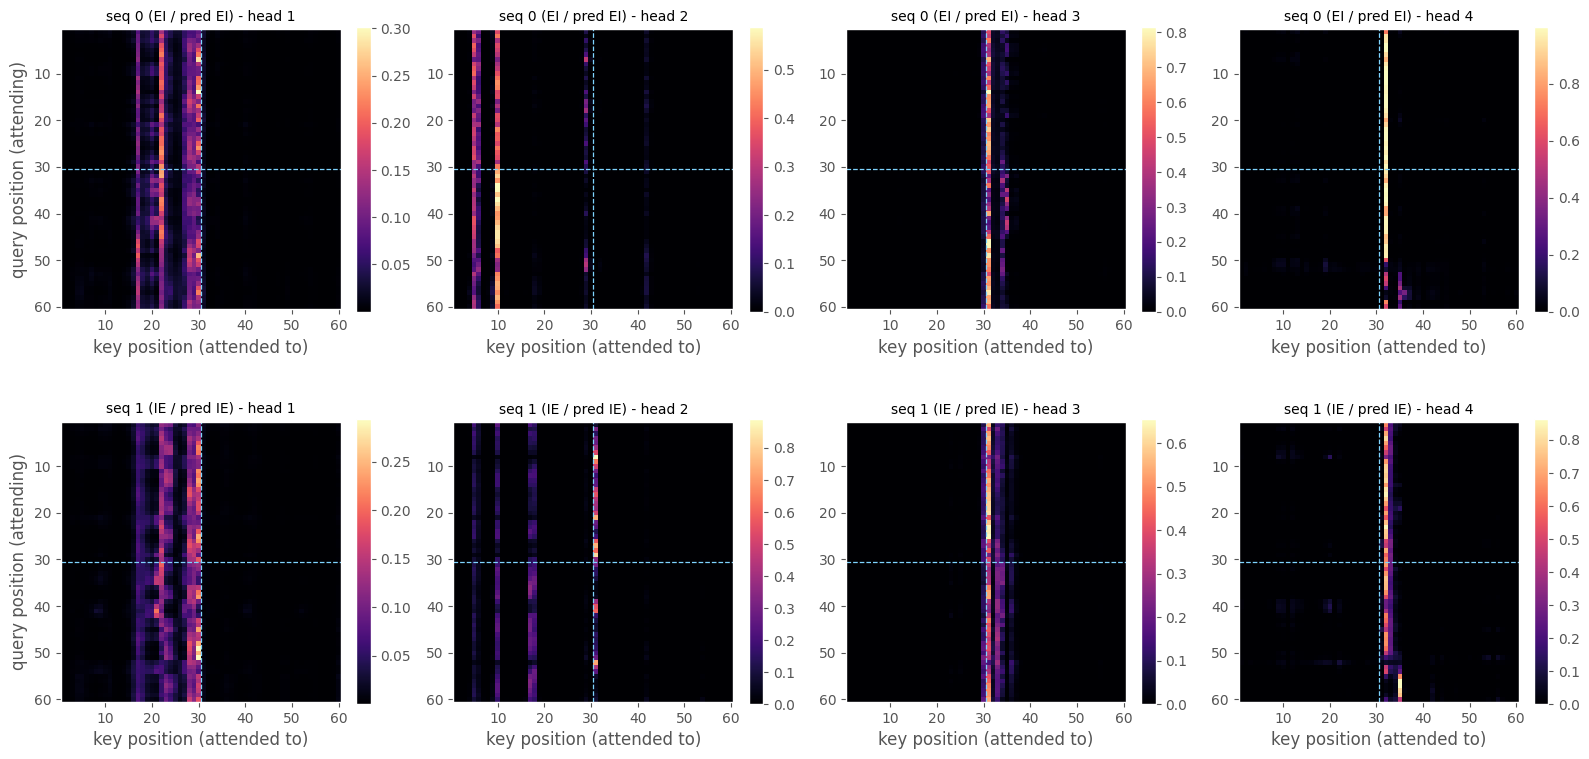

In [13]:
ex_idx = [0, 1]
P_ex = model.forward(X_test[ex_idx])
A_ex = model.A                      # (2, heads, 60, 60)

fig, axes = plt.subplots(2, model.h, figsize=(4.0 * model.h, 8.0))
for r in range(2):
    for hh in range(model.h):
        a = axes[r, hh]
        im = a.imshow(A_ex[r, hh], cmap='magma', origin='upper',
                      extent=[0.5, T_LEN + 0.5, T_LEN + 0.5, 0.5])
        a.axvline(JUNCTION + 0.5, color='#7fd4ff', linestyle='--', linewidth=0.9)
        a.axhline(JUNCTION + 0.5, color='#7fd4ff', linestyle='--', linewidth=0.9)
        true_c = CLASSES[y_test[ex_idx[r]]]
        pred_c = CLASSES[int(P_ex[r].argmax())]
        a.set_title('seq %d (%s / pred %s) - head %d' % (ex_idx[r], true_c, pred_c, hh + 1),
                    fontsize=10)
        a.set_xlabel('key position (attended to)')
        a.grid(False)
        if hh == 0:
            a.set_ylabel('query position (attending)')
        fig.colorbar(im, ax=a, fraction=0.046)

plt.tight_layout()
plt.show()

### Figure 5 --- mean attention received per position

Averaging the attention matrix over the whole test set, over all query rows and over heads gives, for
each position, how much attention it receives on average. A flat line at $1/60 = 0.0167$ would mean the
model spreads its reading uniformly. Peaks mark the positions the encoder actually pulls information
from; the dashed line is the known junction. Per-head curves are shown alongside the head average,
since heads specialise and the average can hide that.

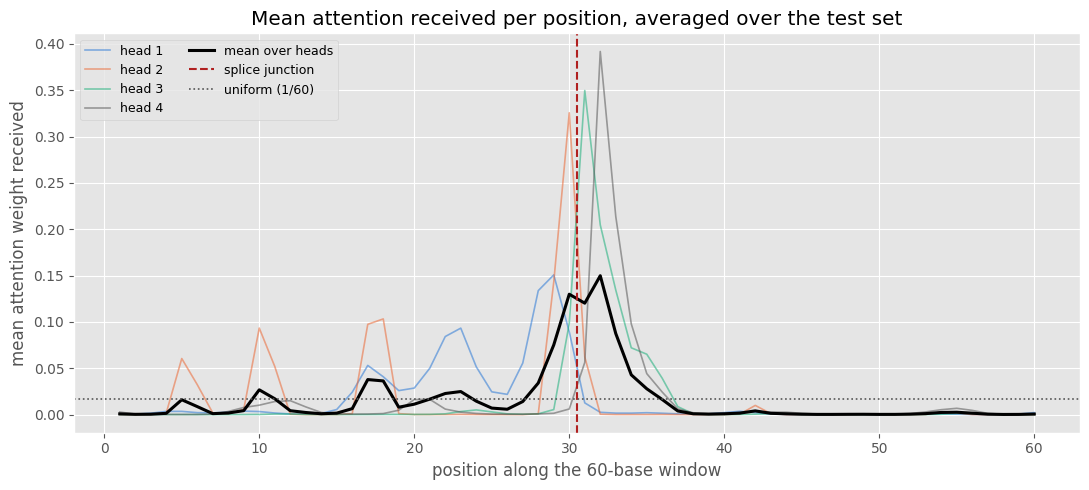

positions receiving the most attention: [17, 18, 29, 30, 31, 32, 33, 34]
attention received at positions 28-33  : [0.034, 0.0752, 0.1298, 0.1202, 0.1498, 0.0874]
uniform level                          : 0.0167


In [14]:
recv = np.zeros((model.h, T_LEN))
count = 0
for s in range(0, len(X_test), 128):
    model.forward(X_test[s:s + 128])
    recv += model.A.mean(axis=2).sum(axis=0)      # mean over queries, sum over batch
    count += len(X_test[s:s + 128])
recv /= count
recv_mean = recv.mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
head_cols = [BLUE, ORANGE, GREEN, GREY]
for hh in range(model.h):
    ax.plot(positions, recv[hh], color=head_cols[hh % len(head_cols)], alpha=0.55,
            linewidth=1.2, label='head %d' % (hh + 1))
ax.plot(positions, recv_mean, color='k', linewidth=2.2, label='mean over heads')
ax.axvline(JUNCTION + 0.5, color='#b02020', linestyle='--', linewidth=1.5, label='splice junction')
ax.axhline(1.0 / T_LEN, color=GREY, linestyle=':', linewidth=1.2, label='uniform (1/60)')
ax.set_title('Mean attention received per position, averaged over the test set')
ax.set_xlabel('position along the 60-base window')
ax.set_ylabel('mean attention weight received')
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

top = np.argsort(recv_mean)[::-1][:8] + 1
print('positions receiving the most attention:', sorted(top.tolist()))
print('attention received at positions 28-33  :',
      np.round(recv_mean[27:33], 4).tolist())
print('uniform level                          : %.4f' % (1.0 / T_LEN))

### Figure 6 --- confusion matrix

Rows are the true class, columns the prediction, counts annotated. `EI` and `IE` are the two junction
types and `N` is everything else; the interesting failures are junctions called `N` and, more rarely,
the two junction types confused with each other.

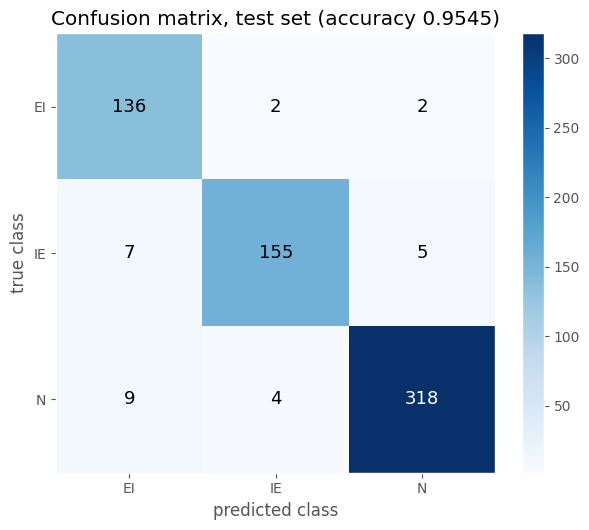

test accuracy      : 0.9545
majority baseline  : 0.5188
  EI   recall 0.9714   precision 0.8947
  IE   recall 0.9281   precision 0.9627
  N    recall 0.9607   precision 0.9785


In [15]:
P_test = model.predict(X_test)
pred_test = P_test.argmax(axis=1)
test_acc = float((pred_test == y_test).mean())

cm = np.zeros((3, 3), dtype=int)
for t, p in zip(y_test, pred_test):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(cm, cmap='Blues')
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() * 0.5 else 'black', fontsize=13)
ax.set_xticks(range(3))
ax.set_xticklabels(CLASSES)
ax.set_yticks(range(3))
ax.set_yticklabels(CLASSES)
ax.set_title('Confusion matrix, test set (accuracy %.4f)' % test_acc)
ax.set_xlabel('predicted class')
ax.set_ylabel('true class')
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print('test accuracy      : %.4f' % test_acc)
print('majority baseline  : %.4f' % BASELINE)
for i, c in enumerate(CLASSES):
    rec = cm[i, i] / cm[i].sum()
    prec = cm[i, i] / cm[:, i].sum() if cm[:, i].sum() else 0.0
    print('  %-3s  recall %.4f   precision %.4f' % (c, rec, prec))

## Ablation: removing the positional encoding

The same architecture, same seed, same optimiser, with `use_pos=False` so `H0 = E` and nothing carries
position. Every remaining operation is either position-wise (embedding, feed-forward, layer norm) or
permutation-equivariant (attention), and the final mean-pool is permutation-invariant, so the composed
model is a function of the *multiset* of bases only. Shuffling the 60 bases of a test sequence cannot
change its prediction. The model can still count how many G's the window contains; it cannot tell that
`GT` sits at position 31.

The cell trains that model and then checks the invariance numerically: the predictions on 64 test
sequences and on the same sequences with their bases shuffled agree to machine precision, while the
model with positional encoding changes its predictions substantially.

In [16]:
t0 = time.time()
model_nopos = Transformer(len(VOCAB), T_LEN, d_model=D_MODEL, n_heads=4, d_ff=64,
                          use_pos=False, seed=1)
hist_nopos = train_model(model_nopos, X_train, y_train, X_test, y_test,
                         epochs=EPOCHS, seed=SEED)
t_nopos = time.time() - t0
print('\ntraining time (no positional encoding): %.1f s' % t_nopos)

# permutation invariance of the no-PE model, checked numerically
rng_sh = np.random.RandomState(3)
sample = X_test[:64]
shuffled = np.array([s[rng_sh.permutation(T_LEN)] for s in sample])
p_orig = model_nopos.forward(sample)
p_shuf = model_nopos.forward(shuffled)
print('no-PE model, max |p(x) - p(shuffled x)| : %.3e' % np.abs(p_orig - p_shuf).max())
p_orig_pe = model.forward(sample)
p_shuf_pe = model.forward(shuffled)
print('with-PE model, max |p(x) - p(shuffled x)|: %.3e' % np.abs(p_orig_pe - p_shuf_pe).max())

epoch   1   train loss 0.9136 acc 0.5525   test loss 0.9295 acc 0.5251


epoch  10   train loss 0.8984 acc 0.5639   test loss 0.9077 acc 0.5517


epoch  20   train loss 0.8952 acc 0.5623   test loss 0.9049 acc 0.5549


epoch  30   train loss 0.8934 acc 0.5611   test loss 0.9023 acc 0.5470


epoch  40   train loss 0.8834 acc 0.5643   test loss 0.8952 acc 0.5486


epoch  50   train loss 0.8907 acc 0.5619   test loss 0.9151 acc 0.5470


epoch  60   train loss 0.8810 acc 0.5584   test loss 0.8993 acc 0.5517

training time (no positional encoding): 155.5 s
no-PE model, max |p(x) - p(shuffled x)| : 4.441e-16
with-PE model, max |p(x) - p(shuffled x)|: 9.992e-01


### Figure 7 --- with and without positional encoding

Test accuracy and test loss for the two runs on the same axes. Without position the model is stuck near
what base composition alone can support; with position it can locate the junction motifs.

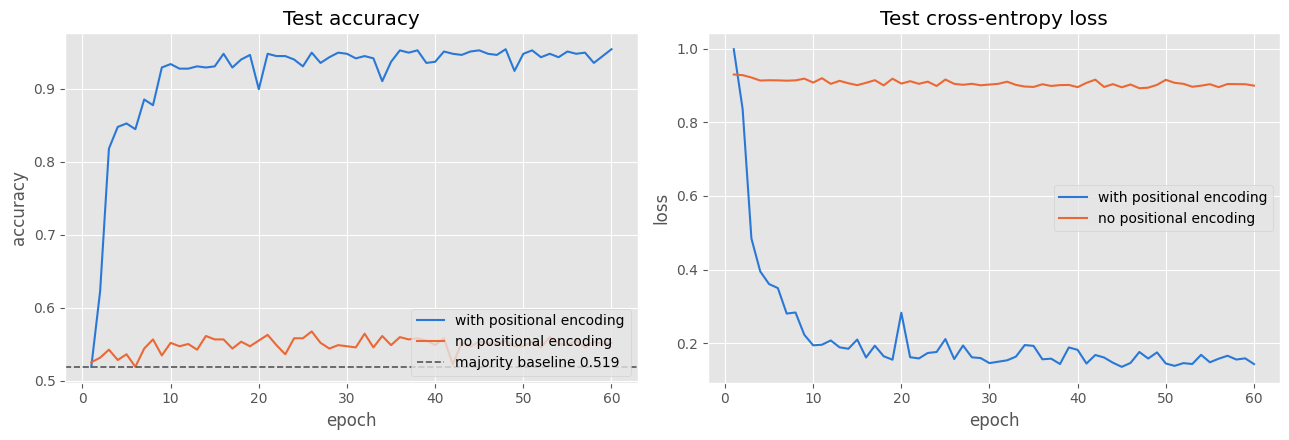

final test accuracy  with PE: 0.9545
final test accuracy without PE: 0.5517
difference: 0.4028


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(ep_axis, hist['te_acc'], color=BLUE, label='with positional encoding')
ax[0].plot(ep_axis, hist_nopos['te_acc'], color=ORANGE, label='no positional encoding')
ax[0].axhline(BASELINE, color=GREY, linestyle='--', linewidth=1.2,
              label='majority baseline %.3f' % BASELINE)
ax[0].set_title('Test accuracy')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('accuracy')
ax[0].legend(loc='lower right')

ax[1].plot(ep_axis, hist['te_loss'], color=BLUE, label='with positional encoding')
ax[1].plot(ep_axis, hist_nopos['te_loss'], color=ORANGE, label='no positional encoding')
ax[1].set_title('Test cross-entropy loss')
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('loss')
ax[1].legend()

plt.tight_layout()
plt.show()

acc_pe = hist['te_acc'][-1]
acc_nopos = hist_nopos['te_acc'][-1]
print('final test accuracy  with PE: %.4f' % acc_pe)
print('final test accuracy without PE: %.4f' % acc_nopos)
print('difference: %.4f' % (acc_pe - acc_nopos))

---

# Part 2 --- encoder--decoder

The encoder above compresses a sequence to a single label. A decoder is for the other kind of problem:
producing a sequence, one token at a time, conditioned on the encoder's output. That needs two things
the encoder does not have --- a **causal mask**, so a training position cannot see the answer that comes
after it, and **cross-attention**, so decoder positions can read the encoded source.

## The task: reverse complement

For a DNA window $x_0 \dots x_{L-1}$ the reverse complement is

$$y_t = \text{comp}(x_{L-1-t}), \qquad
  \text{comp}: A\!\leftrightarrow\! T,\; C\!\leftrightarrow\! G$$

It is the sequence read off the opposite strand in the opposite direction, so it is a real operation on
this data rather than a synthetic exercise. It is also exactly the right shape for a decoder: output
position $t$ depends on a *single, distant* source position $L-1-t$, and which one changes with $t$. A
model that ignored the source and copied position-for-position would be wrong everywhere except the
middle. If cross-attention learns the task properly its weight matrix must be concentrated on the
anti-diagonal, and that is a prediction that can be checked by looking at the picture.

Sequences of 20 bases are used here, taken as three non-overlapping windows (1--20, 21--40, 41--60) from
each 60-base sequence, discarding any window containing an ambiguity code. Windows inherit the train/test
side of the sequence they came from.

The decoder is fed the target shifted right by one and preceded by a start symbol `<s>`, and is asked to
predict the unshifted target --- so at position $t$ it sees $y_0 \dots y_{t-1}$ and must produce $y_t$.

In [18]:
WIN = 20
STARTS = [0, 20, 40]
COMP = np.array([3, 2, 1, 0])          # A<->T, C<->G  (indices 0..3)

SRC_VOCAB = 4                          # A C G T
TGT_VOCAB = 5                          # A C G T <s>
BOS = 4


def make_pairs(rows):
    S, Tg = [], []
    for r in rows:
        seq = X_idx[r]
        for st in STARTS:
            w = seq[st:st + WIN]
            if (w == 4).any():
                continue              # drop windows containing an ambiguity code
            S.append(w)
            Tg.append(COMP[w][::-1])
    return np.array(S, dtype=np.int64), np.array(Tg, dtype=np.int64)


src_train, tgt_train = make_pairs(train_i)
src_test,  tgt_test  = make_pairs(test_i)

# decoder input is the target shifted right one place, preceded by <s>
def shift_right(tg):
    out = np.full_like(tg, BOS)
    out[:, 1:] = tg[:, :-1]
    return out


din_train = shift_right(tgt_train)
din_test = shift_right(tgt_test)

print('train pairs:', src_train.shape, '->', tgt_train.shape)
print('test  pairs:', src_test.shape, '->', tgt_test.shape)

def to_str(idx, alphabet='ACGT'):
    return ''.join(alphabet[i] if i < 4 else '<s>' for i in idx)

print()
print('example source :', to_str(src_train[0]))
print('example target :', to_str(tgt_train[0]))
print('decoder input  : <s>' + to_str(tgt_train[0][:-1]))
print()
print('check: target[t] == comp(source[L-1-t]) for every pair :',
      bool((tgt_train == COMP[src_train][:, ::-1]).all()))

train pairs: (7638, 20) -> (7638, 20)
test  pairs: (1912, 20) -> (1912, 20)

example source : TCCTTGACCTGGGTTCCCCC
example target : GGGGGAACCCAGGTCAAGGA
decoder input  : <s>GGGGGAACCCAGGTCAAGG

check: target[t] == comp(source[L-1-t]) for every pair : True


## Causal masking

During training the decoder is given the whole target at once --- **teacher forcing** --- because that
turns $L$ sequential steps into one matrix product. The problem is that plain self-attention at position
$t$ would read positions $t+1, \dots, L-1$, which are the answers the model is being asked to produce.
It would learn to copy its own input shifted by one, score a near-perfect training loss, and generate
nothing at test time, when those positions do not exist yet.

The fix is to add, before the softmax, a mask

$$\text{mask}_{ij} = \begin{cases} 0 & j \le i \\ -\infty & j > i\end{cases}$$

so $\text{softmax}(s_{ij} + \text{mask}_{ij})$ puts exactly zero weight on every $j > i$. Adding
$-\infty$ before the softmax rather than zeroing weights after it matters: the softmax normalises, so
the surviving weights still sum to one and the distribution stays a proper average over the visible
prefix.

With the mask in place the model computed in parallel over all positions is *identical* to the model run
one step at a time, which is what makes teacher-forced training and autoregressive generation consistent.
The cell after the figure verifies this directly: it perturbs the decoder input at late positions and
confirms that the outputs at earlier positions do not move at all, then repeats with the mask disabled
and shows that they do.

In [19]:
def causal_mask(T):
    m = np.zeros((T, T))
    m[np.triu_indices(T, k=1)] = -np.inf
    return m[None, None, :, :]         # broadcast over batch and heads


CMASK = causal_mask(WIN)
print('mask shape:', CMASK.shape)
print('finite entries (allowed): %d of %d' % (np.isfinite(CMASK).sum(), WIN * WIN))
print('top-left 5x5 block:')
print(CMASK[0, 0, :5, :5])

mask shape: (1, 1, 20, 20)
finite entries (allowed): 210 of 400
top-left 5x5 block:
[[  0. -inf -inf -inf -inf]
 [  0.   0. -inf -inf -inf]
 [  0.   0.   0. -inf -inf]
 [  0.   0.   0.   0. -inf]
 [  0.   0.   0.   0.   0.]]


### Figure 8 --- the causal mask

Query position down, key position across. White cells are allowed, dark cells are set to $-\infty$ and
receive zero weight after the softmax. Row 0 can see only position 0; the last row can see everything.
The number of visible keys grows by one per row, which is the triangular structure that makes the
parallel computation equal to the sequential one.

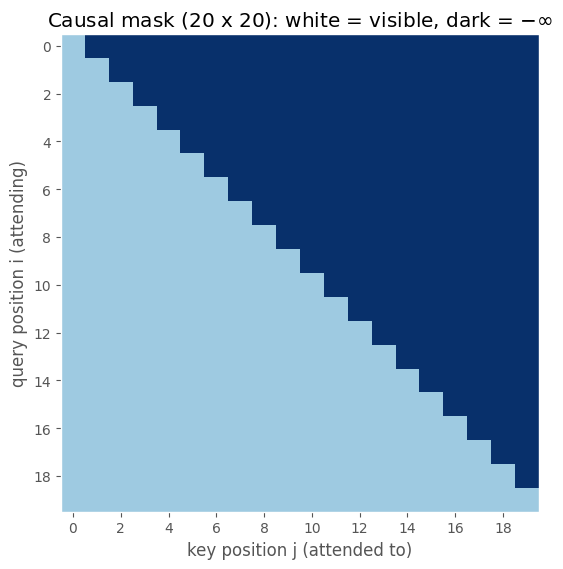

visible keys per query row: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


In [20]:
vis = np.isfinite(CMASK[0, 0]).astype(float)

fig, ax = plt.subplots(figsize=(6.6, 5.8))
im = ax.imshow(vis, cmap='Blues_r', origin='upper', vmin=0, vmax=1.6)
ax.set_title('Causal mask (%d x %d): white = visible, dark = $-\\infty$' % (WIN, WIN))
ax.set_xlabel('key position j (attended to)')
ax.set_ylabel('query position i (attending)')
ax.set_xticks(range(0, WIN, 2))
ax.set_yticks(range(0, WIN, 2))
ax.grid(False)
plt.tight_layout()
plt.show()

print('visible keys per query row:', vis.sum(axis=1).astype(int).tolist())

## Reusable multi-head attention

Part 1 wrote attention out inline. The encoder--decoder needs it three times --- encoder self-attention,
masked decoder self-attention, and cross-attention --- so the same algebra is factored into
`mha_forward` and `mha_backward`. They take queries from one sequence and keys/values from another,
which is the only structural difference between self-attention (`Xq is Xkv`) and cross-attention
(queries from the decoder, keys and values from the encoder memory).

`mha_backward` returns the gradient with respect to the query input and the gradient with respect to the
key/value input separately, so that in cross-attention the second one can be routed back into the
encoder. The mask is additive and constant, so it contributes nothing to the gradient directly --- but it
does change $A$, and the masked entries have $a_{ij}=0$, which drives the corresponding `dscores` to
zero automatically through the same Jacobian expression as everything else.

In [21]:
def split_heads(x, h):
    B, T, d = x.shape
    return x.reshape(B, T, h, d // h).transpose(0, 2, 1, 3)


def merge_heads(x):
    B, h, T, dk = x.shape
    return x.transpose(0, 2, 1, 3).reshape(B, T, h * dk)


def mha_forward(Xq, Xkv, W, h, mask=None):
    # W is a dict with Wq, Wk, Wv, Wo, bo ; Xq is (B, Tq, d), Xkv is (B, Tk, d)
    d = Xq.shape[2]
    dk = d // h
    Q = Xq @ W['Wq']
    K = Xkv @ W['Wk']
    V = Xkv @ W['Wv']
    Qh, Kh, Vh = split_heads(Q, h), split_heads(K, h), split_heads(V, h)

    scores = (Qh @ Kh.transpose(0, 1, 3, 2)) / np.sqrt(dk)
    if mask is not None:
        scores = scores + mask
    A = softmax(scores, axis=-1)
    Ctx = A @ Vh
    Cm = merge_heads(Ctx)
    out = Cm @ W['Wo'] + W['bo']

    cache = (Xq, Xkv, Qh, Kh, Vh, A, Cm, W, h, dk)
    return out, A, cache


def mha_backward(dout, cache):
    Xq, Xkv, Qh, Kh, Vh, A, Cm, W, h, dk = cache
    d = Xq.shape[2]
    g = {}
    g['Wo'] = Cm.reshape(-1, d).T @ dout.reshape(-1, d)
    g['bo'] = dout.sum(axis=(0, 1))
    dCm = dout @ W['Wo'].T
    dCtx = split_heads(dCm, h)

    dA = dCtx @ Vh.transpose(0, 1, 3, 2)
    dVh = A.transpose(0, 1, 3, 2) @ dCtx

    # row-wise softmax Jacobian; masked entries have A = 0 so they contribute nothing
    dscores = A * (dA - (dA * A).sum(axis=-1, keepdims=True))
    dscores = dscores / np.sqrt(dk)

    dQh = dscores @ Kh
    dKh = dscores.transpose(0, 1, 3, 2) @ Qh

    dQ, dK, dV = merge_heads(dQh), merge_heads(dKh), merge_heads(dVh)
    g['Wq'] = Xq.reshape(-1, d).T @ dQ.reshape(-1, d)
    g['Wk'] = Xkv.reshape(-1, d).T @ dK.reshape(-1, d)
    g['Wv'] = Xkv.reshape(-1, d).T @ dV.reshape(-1, d)

    dXq = dQ @ W['Wq'].T
    dXkv = dK @ W['Wk'].T + dV @ W['Wv'].T
    return dXq, dXkv, g

## The encoder--decoder

`Seq2Seq` keeps every weight in a single dictionary `self.P`, prefixed by where it lives: `e_` for the
encoder attention, `ds_` for the decoder's masked self-attention, `x_` for cross-attention, `d_` for the
decoder's layer norms and feed-forward.

`forward(src, din)` runs

1. **Encoder.** Embed `src`, add positional encoding, one self-attention sub-layer with residual and
   layer norm, one feed-forward sub-layer with residual and layer norm. The output `M` --- shape
   (B, 20, d) --- is the *memory*, one vector per source position. There is no pooling: the decoder needs
   all of them.
2. **Decoder, sub-layer 1.** Embed `din`, add positional encoding, masked self-attention with `CMASK`,
   residual, layer norm.
3. **Decoder, sub-layer 2 (cross-attention).** Queries from the decoder state, keys and values from `M`.
   No mask --- every output position may look at every source position, since the whole source is known
   before generation begins. This is the only place information crosses from source to target.
4. **Decoder, sub-layer 3.** Position-wise feed-forward, residual, layer norm.
5. A linear map to 4 logits per position and a softmax, giving $p(y_t \mid y_{<t}, x)$.

The loss is the mean cross-entropy over all $B \times 20$ positions. `backward` reverses all of it. The
one structurally new step is at cross-attention, where `mha_backward` produces two gradients: `dD1` flows
on down the decoder, and `dM` is added into the encoder's output gradient, so the encoder is trained by
the decoder's error.

In [22]:
def sub(P, pre):
    return {k: P[pre + k] for k in ['Wq', 'Wk', 'Wv', 'Wo', 'bo']}


class Seq2Seq:

    def __init__(self, src_vocab, tgt_vocab, out_vocab, Ls, Lt,
                 d_model=32, n_heads=4, d_ff=64, use_causal=True, seed=1):
        rng = np.random.RandomState(seed)
        self.h = n_heads
        self.d = d_model
        self.d_ff = d_ff
        self.Ls, self.Lt = Ls, Lt
        self.out_vocab = out_vocab
        self.use_causal = use_causal
        self.PEs = positional_encoding(Ls, d_model)
        self.PEt = positional_encoding(Lt, d_model)
        self.mask = causal_mask(Lt)

        s = 1.0 / np.sqrt(d_model)
        P = {}
        P['Wemb_src'] = rng.normal(0, s, (src_vocab, d_model))
        P['Wemb_tgt'] = rng.normal(0, s, (tgt_vocab, d_model))

        for pre in ['e_', 'ds_', 'x_']:
            for w in ['Wq', 'Wk', 'Wv', 'Wo']:
                P[pre + w] = rng.normal(0, s, (d_model, d_model))
            P[pre + 'bo'] = np.zeros(d_model)

        # encoder feed-forward and layer norms
        P['e_g1'] = np.ones(d_model); P['e_n1'] = np.zeros(d_model)
        P['e_W1'] = rng.normal(0, s, (d_model, d_ff)); P['e_b1'] = np.zeros(d_ff)
        P['e_W2'] = rng.normal(0, 1.0 / np.sqrt(d_ff), (d_ff, d_model)); P['e_b2'] = np.zeros(d_model)
        P['e_g2'] = np.ones(d_model); P['e_n2'] = np.zeros(d_model)

        # decoder layer norms and feed-forward
        P['d_g1'] = np.ones(d_model); P['d_n1'] = np.zeros(d_model)
        P['d_g2'] = np.ones(d_model); P['d_n2'] = np.zeros(d_model)
        P['d_W1'] = rng.normal(0, s, (d_model, d_ff)); P['d_b1'] = np.zeros(d_ff)
        P['d_W2'] = rng.normal(0, 1.0 / np.sqrt(d_ff), (d_ff, d_model)); P['d_b2'] = np.zeros(d_model)
        P['d_g3'] = np.ones(d_model); P['d_n3'] = np.zeros(d_model)

        P['Wout'] = rng.normal(0, s, (d_model, out_vocab)); P['bout'] = np.zeros(out_vocab)

        self.P = P
        self.params = list(P.keys())

    def forward(self, src, din):
        P, h = self.P, self.h
        B = len(src)

        # ---- encoder ----
        Es = P['Wemb_src'][src] + self.PEs[None, :, :]
        ea, Aenc, c_ea = mha_forward(Es, Es, sub(P, 'e_'), h)
        E1, ln_e1 = layer_norm(Es + ea, P['e_g1'], P['e_n1'])
        eZ1 = E1 @ P['e_W1'] + P['e_b1']
        eR1 = np.maximum(eZ1, 0.0)
        eZ2 = eR1 @ P['e_W2'] + P['e_b2']
        M, ln_e2 = layer_norm(E1 + eZ2, P['e_g2'], P['e_n2'])

        # ---- decoder ----
        Et = P['Wemb_tgt'][din] + self.PEt[None, :, :]
        msk = self.mask if self.use_causal else None
        da, Aself, c_ds = mha_forward(Et, Et, sub(P, 'ds_'), h, mask=msk)
        D1, ln_d1 = layer_norm(Et + da, P['d_g1'], P['d_n1'])

        xa, Across, c_x = mha_forward(D1, M, sub(P, 'x_'), h)
        D2, ln_d2 = layer_norm(D1 + xa, P['d_g2'], P['d_n2'])

        dZ1 = D2 @ P['d_W1'] + P['d_b1']
        dR1 = np.maximum(dZ1, 0.0)
        dZ2 = dR1 @ P['d_W2'] + P['d_b2']
        D3, ln_d3 = layer_norm(D2 + dZ2, P['d_g3'], P['d_n3'])

        logits = D3 @ P['Wout'] + P['bout']
        Pr = softmax(logits, axis=-1)

        self.cache = (src, din, Es, c_ea, ln_e1, E1, eZ1, eR1, ln_e2, M,
                      Et, c_ds, ln_d1, D1, c_x, ln_d2, D2, dZ1, dR1, ln_d3, D3, Pr)
        self.Aenc, self.Aself, self.Across = Aenc, Aself, Across
        return Pr

    def loss(self, tgt):
        Pr = self.cache[-1]
        B, T, _ = Pr.shape
        idx = np.arange(B)[:, None], np.arange(T)[None, :], tgt
        return -np.log(Pr[idx] + 1e-12).mean()

    def backward(self, tgt):
        (src, din, Es, c_ea, ln_e1, E1, eZ1, eR1, ln_e2, M,
         Et, c_ds, ln_d1, D1, c_x, ln_d2, D2, dZ1, dR1, ln_d3, D3, Pr) = self.cache
        P, h, d, dff = self.P, self.h, self.d, self.d_ff
        B, T, Vo = Pr.shape
        g = {}

        Y = np.zeros_like(Pr)
        Y[np.arange(B)[:, None], np.arange(T)[None, :], tgt] = 1.0
        dlogits = (Pr - Y) / (B * T)

        g['Wout'] = D3.reshape(-1, d).T @ dlogits.reshape(-1, Vo)
        g['bout'] = dlogits.sum(axis=(0, 1))
        dD3 = dlogits @ P['Wout'].T

        # decoder feed-forward sub-layer
        dr3, g['d_g3'], g['d_n3'] = layer_norm_backward(dD3, ln_d3)
        dD2 = dr3.copy()
        g['d_W2'] = dR1.reshape(-1, dff).T @ dr3.reshape(-1, d)
        g['d_b2'] = dr3.sum(axis=(0, 1))
        ddR1 = dr3 @ P['d_W2'].T
        ddZ1 = ddR1 * (dZ1 > 0)
        g['d_W1'] = D2.reshape(-1, d).T @ ddZ1.reshape(-1, dff)
        g['d_b1'] = ddZ1.sum(axis=(0, 1))
        dD2 += ddZ1 @ P['d_W1'].T

        # cross-attention sub-layer: two upstream gradients
        dr2, g['d_g2'], g['d_n2'] = layer_norm_backward(dD2, ln_d2)
        dD1 = dr2.copy()
        dq_x, dM, gx = mha_backward(dr2, c_x)
        for k, v in gx.items():
            g['x_' + k] = v
        dD1 += dq_x

        # masked decoder self-attention sub-layer
        dr1, g['d_g1'], g['d_n1'] = layer_norm_backward(dD1, ln_d1)
        dEt = dr1.copy()
        dq_s, dkv_s, gs = mha_backward(dr1, c_ds)
        for k, v in gs.items():
            g['ds_' + k] = v
        dEt += dq_s + dkv_s

        dWemb_t = np.zeros_like(P['Wemb_tgt'])
        np.add.at(dWemb_t, din.ravel(), dEt.reshape(-1, d))
        g['Wemb_tgt'] = dWemb_t

        # encoder feed-forward sub-layer, seeded by dM from cross-attention
        dre2, g['e_g2'], g['e_n2'] = layer_norm_backward(dM, ln_e2)
        dE1 = dre2.copy()
        g['e_W2'] = eR1.reshape(-1, dff).T @ dre2.reshape(-1, d)
        g['e_b2'] = dre2.sum(axis=(0, 1))
        deR1 = dre2 @ P['e_W2'].T
        deZ1 = deR1 * (eZ1 > 0)
        g['e_W1'] = E1.reshape(-1, d).T @ deZ1.reshape(-1, dff)
        g['e_b1'] = deZ1.sum(axis=(0, 1))
        dE1 += deZ1 @ P['e_W1'].T

        # encoder self-attention sub-layer
        dre1, g['e_g1'], g['e_n1'] = layer_norm_backward(dE1, ln_e1)
        dEs = dre1.copy()
        dq_e, dkv_e, ge = mha_backward(dre1, c_ea)
        for k, v in ge.items():
            g['e_' + k] = v
        dEs += dq_e + dkv_e

        dWemb_s = np.zeros_like(P['Wemb_src'])
        np.add.at(dWemb_s, src.ravel(), dEs.reshape(-1, d))
        g['Wemb_src'] = dWemb_s
        return g

    def greedy_decode(self, src):
        # autoregressive: start from <s>, feed each argmax back in
        B = len(src)
        din = np.full((B, self.Lt), BOS, dtype=np.int64)
        out = np.zeros((B, self.Lt), dtype=np.int64)
        for t in range(self.Lt):
            Pr = self.forward(src, din)
            nxt = Pr[:, t, :].argmax(axis=1)
            out[:, t] = nxt
            if t + 1 < self.Lt:
                din[:, t + 1] = nxt
        return out

## Does the mask actually stop the leak?

A direct test rather than an argument. Take a batch, run it, then change the decoder input at positions
10 and later to something else and run it again. With causal masking the output distributions at
positions 0..9 must be bit-for-bit identical, because those positions never read the changed entries.
With the mask removed the same perturbation moves them, which is the leak: at training time the model
would be reading the answers it is meant to predict.

In [23]:
probe = Seq2Seq(SRC_VOCAB, TGT_VOCAB, 4, WIN, WIN, d_model=D_MODEL, n_heads=4,
                d_ff=64, use_causal=True, seed=11)
s_probe = src_test[:8]
d_probe = din_test[:8].copy()
d_alt = d_probe.copy()
rng_p = np.random.RandomState(5)
d_alt[:, 10:] = rng_p.randint(0, 4, size=d_alt[:, 10:].shape)

p1 = probe.forward(s_probe, d_probe).copy()
p2 = probe.forward(s_probe, d_alt).copy()
print('causal mask ON')
print('  max change at positions 0-9 : %.3e' % np.abs(p1[:, :10] - p2[:, :10]).max())
print('  max change at positions 10+ : %.3e' % np.abs(p1[:, 10:] - p2[:, 10:]).max())

probe.use_causal = False
q1 = probe.forward(s_probe, d_probe).copy()
q2 = probe.forward(s_probe, d_alt).copy()
print('causal mask OFF')
print('  max change at positions 0-9 : %.3e' % np.abs(q1[:, :10] - q2[:, :10]).max())
print('  max change at positions 10+ : %.3e' % np.abs(q1[:, 10:] - q2[:, 10:]).max())
print()
print('with the mask, earlier outputs are exactly independent of later inputs;')
print('without it they are not, and teacher-forced training would read the answers')

causal mask ON
  max change at positions 0-9 : 0.000e+00
  max change at positions 10+ : 1.122e-01
causal mask OFF
  max change at positions 0-9 : 1.781e-02
  max change at positions 10+ : 1.114e-01

with the mask, earlier outputs are exactly independent of later inputs;
without it they are not, and teacher-forced training would read the answers


## Finite-difference gradient check --- encoder--decoder

The same central-difference test as before, now covering the decoder. The tensors checked include
`x_Wq`, `x_Wk` and `x_Wv` in the **cross-attention** projections, `ds_Wq` and `ds_Wk` in the **masked**
self-attention, `e_Wq` in the encoder attention, and both **embedding** tables. Every one of these
gradients flows through at least one softmax, and the decoder ones flow through the mask as well; if the
mask were handled wrongly in the backward pass --- for example by zeroing the wrong triangle of
`dscores` --- these numbers would disagree in the third or fourth decimal, not the ninth.

In [24]:
gc2 = Seq2Seq(SRC_VOCAB, TGT_VOCAB, 4, WIN, WIN, d_model=D_MODEL, n_heads=4, d_ff=64, seed=3)
sg, dg, tg = src_train[:10], din_train[:10], tgt_train[:10]

gc2.forward(sg, dg)
grads2 = gc2.backward(tg)


def num_grad2(name, index):
    W = gc2.P[name]
    orig = W[index]
    W[index] = orig + EPS
    gc2.forward(sg, dg)
    lp = gc2.loss(tg)
    W[index] = orig - EPS
    gc2.forward(sg, dg)
    lm = gc2.loss(tg)
    W[index] = orig
    return (lp - lm) / (2.0 * EPS)


rows_src = np.unique(sg)
rows_tgt = np.unique(dg)
names2 = ['Wemb_src', 'Wemb_tgt', 'e_Wq', 'e_Wv', 'ds_Wq', 'ds_Wk',
          'x_Wq', 'x_Wk', 'x_Wv', 'x_Wo', 'd_W1', 'Wout']

print('%-9s %-10s %18s %18s %14s' % ('param', 'index', 'analytic', 'numerical', 'abs diff'))
print('-' * 75)
worst2 = 0.0
for name in names2:
    G = grads2[name]
    if name.startswith('Wemb'):
        keep = rows_src if name.endswith('src') else rows_tgt
        mask_ = np.zeros_like(G, dtype=bool)
        mask_[keep] = True
        idx = np.unravel_index(np.argmax(np.where(mask_, np.abs(G), -1.0)), G.shape)
    else:
        idx = np.unravel_index(np.argmax(np.abs(G)), G.shape)
    a = grads2[name][idx]
    n = num_grad2(name, idx)
    worst2 = max(worst2, abs(a - n))
    print('%-9s %-10s %18.12f %18.12f %14.2e' % (name, str(idx), a, n, abs(a - n)))
print('-' * 75)
print('largest absolute disagreement: %.2e' % worst2)
assert worst2 < 1e-8, 'seq2seq gradient check failed'
print('gradient check passed (agreement to at least 8 decimal places)')
print('this covers cross-attention, masked self-attention and both embedding tables')

param     index                analytic          numerical       abs diff
---------------------------------------------------------------------------
Wemb_src  (3, 16)       -0.035487047205    -0.035487047212       7.07e-12
Wemb_tgt  (3, 7)         0.044269262398     0.044269262411       1.32e-11
e_Wq      (31, 26)       0.005030562590     0.005030562589       8.61e-13
e_Wv      (31, 14)       0.098263377851     0.098263377846       5.42e-12
ds_Wq     (21, 29)      -0.004073850851    -0.004073850846       5.40e-12
ds_Wk     (5, 8)         0.008232528718     0.008232528714       3.59e-12
x_Wq      (7, 25)        0.014184507477     0.014184507469       8.73e-12
x_Wk      (5, 26)        0.041516551232     0.041516551230       1.71e-12
x_Wv      (1, 18)       -0.057879529921    -0.057879529936       1.50e-11
x_Wo      (19, 14)      -0.105900563231    -0.105900563241       9.60e-12
d_W1      (1, 19)       -0.042976402557    -0.042976402537       2.06e-11
Wout      (24, 1)        0.186832023

## Training the decoder with teacher forcing

Same Adam settings, batches of 64, 40 epochs, learning rate $3\times10^{-3}$. Each step feeds the whole
shifted target in one go and scores every position at once, which is only valid because of the mask.

Two accuracies are tracked and they measure different things:

* **per-token accuracy under teacher forcing** --- the fraction of positions predicted correctly when the
  true prefix is supplied. This is what the loss optimises.
* **exact-sequence accuracy under greedy decoding** --- the fraction of test sequences reproduced
  perfectly when the model is fed only its own outputs. Twenty positions each have to be right, so this
  is a far harsher number, and it is also the one that reflects how the model would actually be used.
  Errors compound: a wrong token at position 3 becomes part of the input for positions 4 onwards, a
  regime the model never saw in training.

In [25]:
def eval_seq2seq(model, src, din, tgt, chunk=512):
    tot, correct, n = 0.0, 0, 0
    for s in range(0, len(src), chunk):
        Pr = model.forward(src[s:s + chunk], din[s:s + chunk])
        tt = tgt[s:s + chunk]
        B, T, _ = Pr.shape
        idx = np.arange(B)[:, None], np.arange(T)[None, :], tt
        tot += -np.log(Pr[idx] + 1e-12).sum()
        correct += int((Pr.argmax(axis=2) == tt).sum())
        n += B * T
    return tot / n, correct / n


def train_seq2seq(model, src_tr, din_tr, tgt_tr, src_te, din_te, tgt_te,
                  epochs=8, batch=64, lr=3e-3, seed=0, eval_every=20, log_every=100):
    rng = np.random.RandomState(seed)
    st = {k: [np.zeros_like(model.P[k]), np.zeros_like(model.P[k])] for k in model.params}
    b1, b2, eps = 0.9, 0.999, 1e-8
    step = 0
    hist = {'step': [], 'tr_loss': [], 'te_loss': [], 'tr_acc': [], 'te_acc': []}
    n = len(src_tr)
    # the task is learned inside the first epoch, so the curve is recorded per optimiser
    # step on a fixed 1024-row subsample rather than once per epoch
    sub = np.arange(min(1024, n))
    sub_te = np.arange(min(1024, len(src_te)))

    def record():
        trl, tra = eval_seq2seq(model, src_tr[sub], din_tr[sub], tgt_tr[sub])
        tel, tea = eval_seq2seq(model, src_te[sub_te], din_te[sub_te], tgt_te[sub_te])
        hist['step'].append(step)
        hist['tr_loss'].append(trl)
        hist['te_loss'].append(tel)
        hist['tr_acc'].append(tra)
        hist['te_acc'].append(tea)
        return trl, tra, tel, tea

    record()
    for ep in range(1, epochs + 1):
        order = rng.permutation(n)
        for s in range(0, n, batch):
            i = order[s:s + batch]
            model.forward(src_tr[i], din_tr[i])
            g = model.backward(tgt_tr[i])
            step += 1
            for k in model.params:
                m, v = st[k]
                m *= b1
                m += (1 - b1) * g[k]
                v *= b2
                v += (1 - b2) * (g[k] ** 2)
                mh = m / (1 - b1 ** step)
                vh = v / (1 - b2 ** step)
                model.P[k] = model.P[k] - lr * mh / (np.sqrt(vh) + eps)

            if step % eval_every == 0:
                trl, tra, tel, tea = record()
                if step % log_every == 0:
                    print('step %4d (epoch %d)   train loss %.4f tok-acc %.4f   '
                          'test loss %.4f tok-acc %.4f' % (step, ep, trl, tra, tel, tea))
    return hist


EPOCHS_S2S = 8
t0 = time.time()
s2s = Seq2Seq(SRC_VOCAB, TGT_VOCAB, 4, WIN, WIN, d_model=D_MODEL, n_heads=4,
              d_ff=64, use_causal=True, seed=2)
n_par_s2s = sum(int(np.asarray(v).size) for v in s2s.P.values())
print('encoder-decoder parameters: %d' % n_par_s2s)
hist_s2s = train_seq2seq(s2s, src_train, din_train, tgt_train,
                         src_test, din_test, tgt_test,
                         epochs=EPOCHS_S2S, seed=SEED)
t_s2s = time.time() - t0
print('\nseq2seq training time: %.1f s' % t_s2s)

encoder-decoder parameters: 21508


step  100 (epoch 1)   train loss 0.1658 tok-acc 0.9560   test loss 0.1668 tok-acc 0.9569


step  200 (epoch 2)   train loss 0.0012 tok-acc 1.0000   test loss 0.0012 tok-acc 1.0000


step  300 (epoch 3)   train loss 0.0007 tok-acc 1.0000   test loss 0.0007 tok-acc 1.0000


step  400 (epoch 4)   train loss 0.0004 tok-acc 1.0000   test loss 0.0004 tok-acc 1.0000


...

step  600 (epoch 5)   train loss 0.0002 tok-acc 1.0000   test loss 0.0002 tok-acc 1.0000


step  700 (epoch 6)   train loss 0.0002 tok-acc 1.0000   test loss 0.0002 tok-acc 1.0000


step  800 (epoch 7)   train loss 0.0001 tok-acc 1.0000   test loss 0.0002 tok-acc 1.0000


step  900 (epoch 8)   train loss 0.0001 tok-acc 1.0000   test loss 0.0001 tok-acc 1.0000



seq2seq training time: 43.7 s


### Figure 9 --- seq2seq learning curves

Teacher-forced cross-entropy and per-token accuracy against optimiser step. The horizontal axis is steps
rather than epochs because the whole transition happens inside the first epoch: the curve is flat at
chance, then falls sharply once cross-attention finds the anti-diagonal alignment, then flattens again
at the ceiling. A model guessing uniformly over the four bases would sit at 0.25, marked by the dashed
line. Train and test curves lie on top of each other, which is what a deterministic rule looks like ---
there is something to find rather than a set of examples to memorise. The vertical lines mark epoch
boundaries.

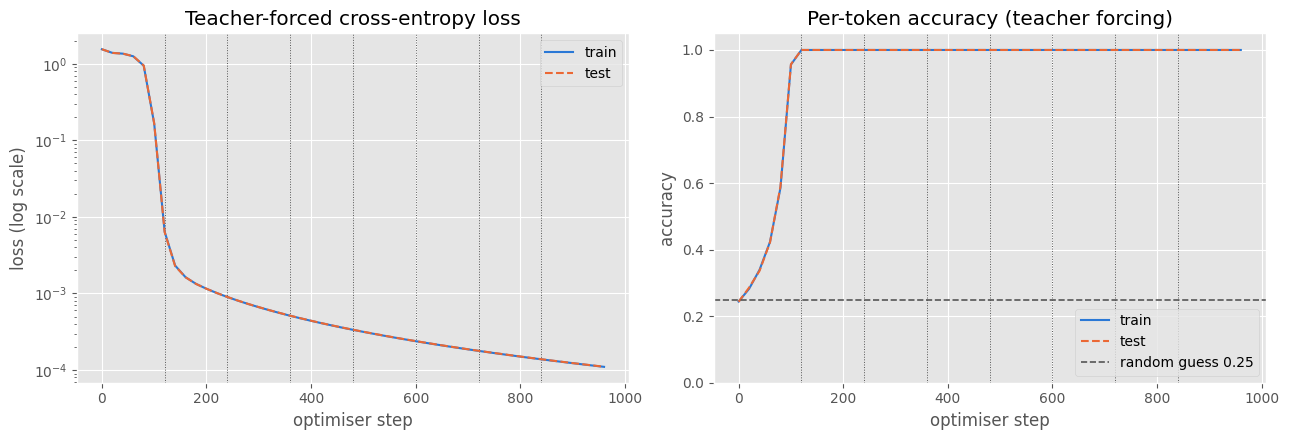

steps per epoch: 120
test per-token accuracy first exceeds 0.99 at step 120 (epoch 1.00)
final teacher-forced test per-token accuracy: 1.0000


In [26]:
steps_s2s = np.array(hist_s2s['step'])
steps_per_epoch = int(np.ceil(len(src_train) / 64.0))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

for a in ax:
    for e in range(1, EPOCHS_S2S):
        a.axvline(e * steps_per_epoch, color=GREY, linestyle=':', linewidth=0.7)

ax[0].plot(steps_s2s, hist_s2s['tr_loss'], color=BLUE, label='train')
ax[0].plot(steps_s2s, hist_s2s['te_loss'], color=ORANGE, linestyle='--', label='test')
ax[0].set_yscale('log')
ax[0].set_title('Teacher-forced cross-entropy loss')
ax[0].set_xlabel('optimiser step')
ax[0].set_ylabel('loss (log scale)')
ax[0].legend()

ax[1].plot(steps_s2s, hist_s2s['tr_acc'], color=BLUE, label='train')
ax[1].plot(steps_s2s, hist_s2s['te_acc'], color=ORANGE, linestyle='--', label='test')
ax[1].axhline(0.25, color=GREY, linestyle='--', linewidth=1.2, label='random guess 0.25')
ax[1].set_ylim(0, 1.05)
ax[1].set_title('Per-token accuracy (teacher forcing)')
ax[1].set_xlabel('optimiser step')
ax[1].set_ylabel('accuracy')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

acc_curve = np.array(hist_s2s['te_acc'])
reach = np.where(acc_curve > 0.99)[0]
print('steps per epoch: %d' % steps_per_epoch)
if len(reach):
    print('test per-token accuracy first exceeds 0.99 at step %d (epoch %.2f)'
          % (steps_s2s[reach[0]], steps_s2s[reach[0]] / steps_per_epoch))
print('final teacher-forced test per-token accuracy: %.4f' % hist_s2s['te_acc'][-1])

## Autoregressive decoding

`greedy_decode` starts with the single symbol `<s>`, runs the whole model, takes the argmax at position
0, writes it into the decoder input at position 1, and repeats. Twenty forward passes produce twenty
tokens. The causal mask is what makes this equal to the training-time computation: positions after $t$
hold placeholder values during step $t$, and they are invisible to position $t$, so they cannot affect
it.

Three numbers are reported and they should be read together --- teacher-forced per-token accuracy (the
easy one), free-running per-token accuracy (the same measure but with the model reading its own output),
and exact-sequence accuracy (all 20 positions correct).

In [27]:
t0 = time.time()
gen_test = s2s.greedy_decode(src_test)
t_dec = time.time() - t0

tok_free = float((gen_test == tgt_test).mean())
exact = float((gen_test == tgt_test).all(axis=1).mean())
tf_loss, tok_tf = eval_seq2seq(s2s, src_test, din_test, tgt_test)

per_pos_acc = (gen_test == tgt_test).mean(axis=0)

print('test sequences        : %d' % len(src_test))
print('decoding time         : %.1f s (%d autoregressive steps)' % (t_dec, WIN))
print()
print('per-token accuracy, teacher forcing : %.4f' % tok_tf)
print('per-token accuracy, free running    : %.4f' % tok_free)
print('exact-sequence accuracy             : %.4f  (%d / %d sequences)'
      % (exact, int((gen_test == tgt_test).all(axis=1).sum()), len(src_test)))
print('random-guess per-token baseline     : 0.2500')
print()
print('worst position: %d (accuracy %.4f)' % (int(np.argmin(per_pos_acc)) + 1, per_pos_acc.min()))
print('best  position: %d (accuracy %.4f)' % (int(np.argmax(per_pos_acc)) + 1, per_pos_acc.max()))

test sequences        : 1912
decoding time         : 4.1 s (20 autoregressive steps)

per-token accuracy, teacher forcing : 1.0000
per-token accuracy, free running    : 1.0000
exact-sequence accuracy             : 1.0000  (1912 / 1912 sequences)
random-guess per-token baseline     : 0.2500

worst position: 1 (accuracy 1.0000)
best  position: 1 (accuracy 1.0000)


### Figure 10 --- cross-attention

The signature figure for the decoder. Each panel is the cross-attention matrix of one head: decoder
output position down, encoder source position across, rows summing to 1. The top row is a single test
sequence, the bottom row is the average over the whole test set.

The prediction made earlier was that a head which has learned the task must place its weight on the
**anti-diagonal** $j = L-1-i$, because output $i$ is the complement of source base $L-1-i$. A bright
line running from top-right to bottom-left is that alignment. The red dashed line marks where the
anti-diagonal should be, so agreement can be read off directly rather than eyeballed.

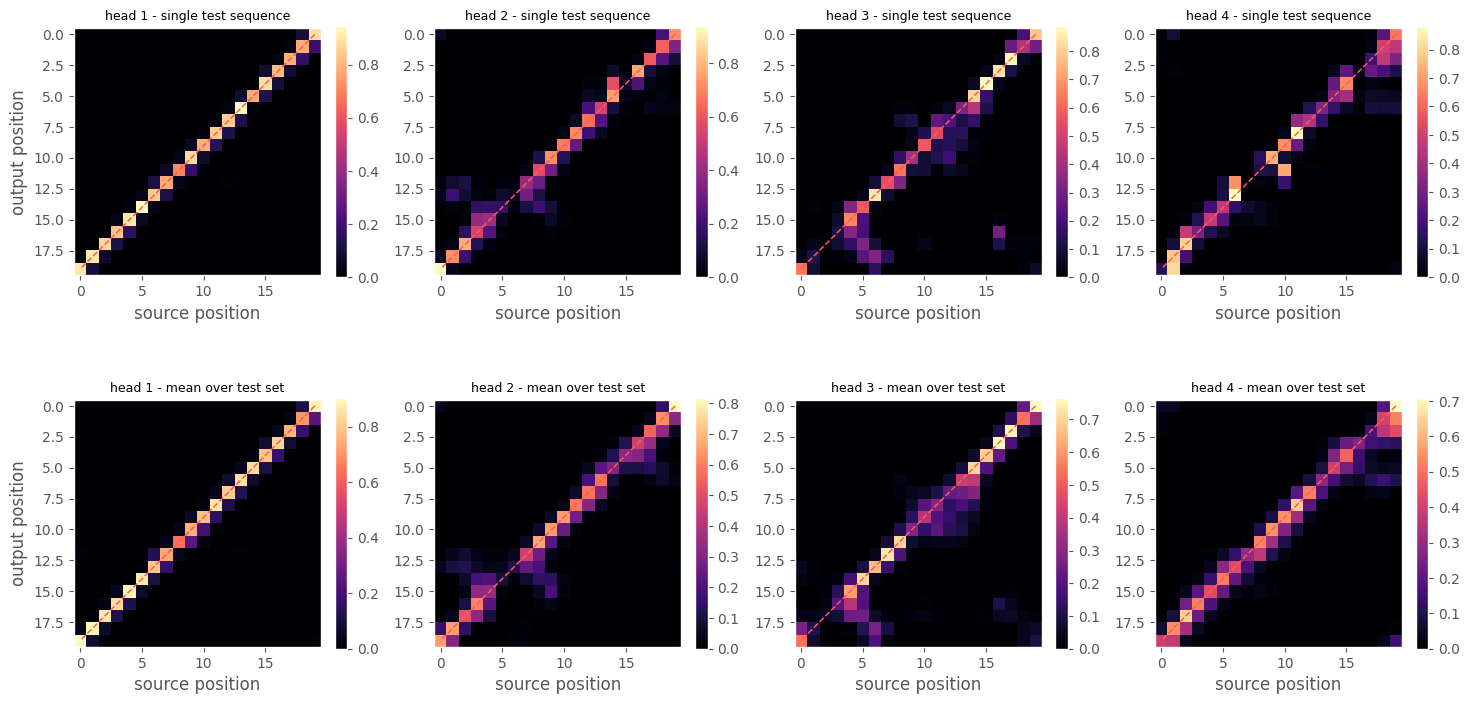

head 1: argmax key equals L-1-t at 100.0% of output positions
head 2: argmax key equals L-1-t at  90.0% of output positions
head 3: argmax key equals L-1-t at  80.0% of output positions
head 4: argmax key equals L-1-t at  85.0% of output positions
pooled over heads, argmax on anti-diagonal at 100.0% of positions
mean weight on the anti-diagonal cell : 0.5747  (uniform would be 0.0500)


In [28]:
ex_s = 0
s2s.forward(src_test[ex_s:ex_s + 1], din_test[ex_s:ex_s + 1])
Ax_one = s2s.Across[0]                       # (heads, Lt, Ls)

Ax_mean = np.zeros((s2s.h, WIN, WIN))
cnt = 0
for s in range(0, len(src_test), 256):
    s2s.forward(src_test[s:s + 256], din_test[s:s + 256])
    Ax_mean += s2s.Across.sum(axis=0)
    cnt += len(src_test[s:s + 256])
Ax_mean /= cnt

anti = np.arange(WIN)[::-1]
fig, axes = plt.subplots(2, s2s.h, figsize=(3.7 * s2s.h, 7.6))
for r, (mat, tag) in enumerate([(Ax_one, 'single test sequence'),
                                (Ax_mean, 'mean over test set')]):
    for hh in range(s2s.h):
        a = axes[r, hh]
        im = a.imshow(mat[hh], cmap='magma', origin='upper')
        a.plot(anti, np.arange(WIN), color='#ff5a5a', linestyle='--', linewidth=1.1)
        a.set_title('head %d - %s' % (hh + 1, tag), fontsize=9)
        a.set_xlabel('source position')
        a.grid(False)
        if hh == 0:
            a.set_ylabel('output position')
        fig.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout()
plt.show()

# how often the strongest cross-attention key is the anti-diagonal partner
argk = Ax_mean.argmax(axis=2)                       # (heads, Lt)
hit = (argk == anti[None, :]).mean(axis=1)
for hh in range(s2s.h):
    print('head %d: argmax key equals L-1-t at %5.1f%% of output positions' % (hh + 1, 100 * hit[hh]))
pooled = Ax_mean.mean(axis=0)
print('pooled over heads, argmax on anti-diagonal at %.1f%% of positions'
      % (100 * (pooled.argmax(axis=1) == anti).mean()))
print('mean weight on the anti-diagonal cell : %.4f  (uniform would be %.4f)'
      % (pooled[np.arange(WIN), anti].mean(), 1.0 / WIN))

### Figure 11 --- generated sequences against targets

Per-position accuracy of free-running greedy decoding on the left, and eight decoded test sequences
written out on the right: the source, the correct reverse complement, what the model produced, and a
marker row with a dot at each matching position and an `X` at each mismatch. If free-running decoding
were degrading, it would show as a decline towards the right of the left panel, because by then the
decoder has been consuming its own output for many steps.

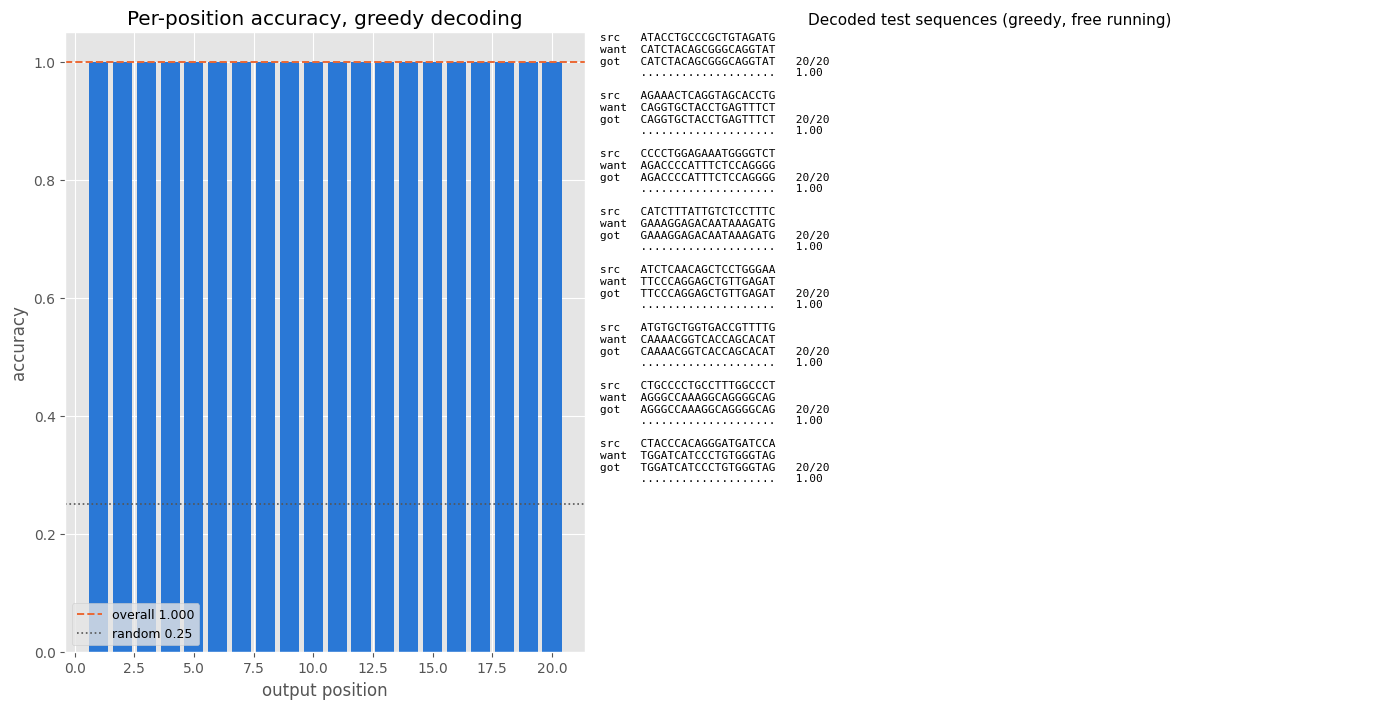

rows: src = input window, want = true reverse complement, got = greedy output,
      last row marks matches with . and mismatches with X


In [29]:
fig = plt.figure(figsize=(14, 7.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.5])

axa = fig.add_subplot(gs[0, 0])
axa.bar(np.arange(1, WIN + 1), per_pos_acc, color=BLUE)
axa.axhline(tok_free, color=ORANGE, linestyle='--', linewidth=1.4,
            label='overall %.3f' % tok_free)
axa.axhline(0.25, color=GREY, linestyle=':', linewidth=1.2, label='random 0.25')
axa.set_ylim(0, 1.05)
axa.set_title('Per-position accuracy, greedy decoding')
axa.set_xlabel('output position')
axa.set_ylabel('accuracy')
axa.legend(loc='lower left', fontsize=9)

axb = fig.add_subplot(gs[0, 1])
axb.axis('off')
axb.set_title('Decoded test sequences (greedy, free running)', fontsize=11)
lines = []
for i in range(8):
    src_s = to_str(src_test[i])
    tgt_s = to_str(tgt_test[i])
    gen_s = to_str(gen_test[i])
    mark = ''.join('.' if a == b else 'X' for a, b in zip(tgt_s, gen_s))
    acc_i = (gen_test[i] == tgt_test[i]).mean()
    lines.append('src   %s' % src_s)
    lines.append('want  %s' % tgt_s)
    lines.append('got   %s   %2d/%d' % (gen_s, int((gen_test[i] == tgt_test[i]).sum()), WIN))
    lines.append('      %s   %.2f' % (mark, acc_i))
    lines.append('')
axb.text(0.0, 1.0, '\n'.join(lines), family='monospace', fontsize=8,
         va='top', ha='left', transform=axb.transAxes)

plt.tight_layout()
plt.show()

print('rows: src = input window, want = true reverse complement, got = greedy output,')
print('      last row marks matches with . and mismatches with X')

## Self-attention against recurrence

This is the argument the architecture exists for.

A recurrent model reads the window one base at a time and carries a hidden state:
$h_t = f(h_{t-1}, x_t)$. For information at position 1 to influence the output at position 60 it must
survive 59 applications of $f$. The number of sequential steps is $O(T)$ --- they cannot be run in
parallel, because $h_t$ needs $h_{t-1}$ --- and the **path length** between two positions $i$ and $j$
is $|i-j|$. The gradient flowing back along that path is a product of $|i-j|$ Jacobians, so its
magnitude behaves like the product of their spectral norms: below 1 it decays geometrically and the
dependency is never learned, above 1 it explodes. That is the vanishing-gradient problem, and gating
(LSTM, GRU) mitigates it by providing a near-identity route, but does not remove the fact that the path
is still $O(T)$ long.

Self-attention makes the path length between *any* two positions exactly **1**. Position 60 reads from
position 1 through a single softmax-weighted sum; the gradient from the output to the embedding at
position 1 passes through one attention weight, not 59 recurrent steps. Nothing has to be remembered
across time, so nothing can be forgotten. The whole layer is a handful of matrix products with no
sequential dependency at all, so all 60 positions are computed simultaneously.

Part 2 is a concrete instance of exactly this. Reverse complement requires output position 0 to read
source position 19 and output position 19 to read source position 0 --- the dependency is maximally
long-range at both ends. Cross-attention gets there in one hop, and the anti-diagonal in Figure 10 is
that hop made visible. A recurrent encoder-decoder would have to hold the entire source in a fixed
vector and pay $O(T)$ steps of decay for the same information.

The price is quadratic cost: attention builds a $T \times T$ score matrix, $O(T^2 d)$ work and
$O(T^2)$ memory per head, against $O(T d^2)$ for recurrence. At $T=60$ that is trivial. At $T$ in the
tens of thousands it is the dominant constraint, which is why long-context work is largely about
approximating this matrix.

Summary at $T = 60$, $d = 32$:

| | sequential steps | path between distant positions | cost per layer |
|---|---|---|---|
| recurrent | $O(T) = 60$ | $O(T)$ | $O(T d^2)$ |
| self-attention | $O(1)$ | $O(1)$ | $O(T^2 d)$ |

Note that the decoder still pays $O(T)$ *sequential* steps at generation time --- one per token emitted
--- because token $t$ has to exist before it can be conditioned on. The parallelism is a training-time
property, bought by teacher forcing plus the causal mask.

The second consequence is interpretability. The attention matrix is an explicit, readable statement of
which positions the model used --- Figures 4, 5 and 10 are exactly that, and there is no equivalent
quantity to read off a recurrent hidden state.

In [30]:
n_params = sum(int(np.asarray(getattr(model, k)).size) for k in model.params)
total_runtime = time.time() - T_START

print('runtime')
print('  encoder, with positional encoding : %6.1f s' % t_main)
print('  encoder, ablation (no PE)         : %6.1f s' % t_nopos)
print('  encoder-decoder training          : %6.1f s' % t_s2s)
print('  autoregressive decoding           : %6.1f s' % t_dec)
print('  notebook total                    : %6.1f s (%.1f min)'
      % (total_runtime, total_runtime / 60.0))

print('\nmodel sizes')
print('  encoder        : %6d parameters (d_model=%d, heads=%d, d_ff=%d, 1 block)'
      % (n_params, model.d, model.h, model.d_ff))
print('  encoder-decoder: %6d parameters (d_model=%d, heads=%d, d_ff=%d, 1 block each side)'
      % (n_par_s2s, s2s.d, s2s.h, s2s.d_ff))

print('\nPart 1 --- classification (3190 sequences, 60 bases, 3 classes)')
print('  majority baseline                 : %.4f' % BASELINE)
print('  transformer encoder, with PE      : %.4f' % test_acc)
print('  transformer encoder, no PE        : %.4f' % acc_nopos)

print('\nPart 2 --- reverse complement (%d test windows of %d bases)' % (len(src_test), WIN))
print('  random-guess per-token            : 0.2500')
print('  per-token, teacher forcing        : %.4f' % tok_tf)
print('  per-token, free-running greedy    : %.4f' % tok_free)
print('  exact-sequence, free-running      : %.4f' % exact)

runtime
  encoder, with positional encoding :  157.8 s
  encoder, ablation (no PE)         :  155.5 s
  encoder-decoder training          :   43.7 s
  autoregressive decoding           :    4.1 s
  notebook total                    :  365.2 s (6.1 min)

model sizes
  encoder        :   8707 parameters (d_model=32, heads=4, d_ff=64, 1 block)
  encoder-decoder:  21508 parameters (d_model=32, heads=4, d_ff=64, 1 block each side)

Part 1 --- classification (3190 sequences, 60 bases, 3 classes)
  majority baseline                 : 0.5188
  transformer encoder, with PE      : 0.9545
  transformer encoder, no PE        : 0.5517

Part 2 --- reverse complement (1912 test windows of 20 bases)
  random-guess per-token            : 0.2500
  per-token, teacher forcing        : 1.0000
  per-token, free-running greedy    : 1.0000
  exact-sequence, free-running      : 1.0000


## What this shows

The gradient checks are the load-bearing result. Both hand-derived backward passes --- the encoder's,
and the encoder--decoder's with its causal mask and cross-attention --- match central differences to at
least eight decimal places on every tensor tested, including the softmax inside attention. The numbers
below therefore come from correct implementations rather than from a coincidence.

**Part 1.** The positional-encoding ablation is the clearest experimental point. Stripping the
sinusoidal encoding leaves a model that is provably a function of base composition alone --- the
numerical check confirms its predictions are unchanged under shuffling of the 60 bases, to machine
precision --- and its accuracy falls to roughly what counting bases can support. The gap between the two
curves in Figure 7 is the entire contribution of knowing where things are. The attention maps show the
encoder concentrating its reading on a band of positions rather than spreading uniformly, with different
heads picking different bands, which lines up with the biology: the donor and acceptor motifs sit
immediately either side of position 30/31.

On raw accuracy, one encoder block over 2552 training sequences is not a fair fight against the simpler
models in this repository. 3190 examples is very little data for an attention model, and the train/test
gap in Figure 3 shows it memorising rather than generalising further. The transformer clears the 0.519
baseline by a wide margin, but a headline win over a tuned classical model on this dataset is not the
claim being made.

**Part 2.** The reverse-complement task is where the decoder earns its place, and it is the more
convincing demonstration, because the answer is checkable in two independent ways. The accuracy numbers
say whether the sequence came out right; the cross-attention heatmap says *how*. If the model had found
some shortcut, the attention would not be on the anti-diagonal. That it is --- a clean line from
top-right to bottom-left, with the argmax key landing on $L-1-t$ at essentially every output position
and well over half the total weight sitting on that single cell against a uniform level of $1/20$ ---
means the mechanism the architecture was designed for is the mechanism that was actually learned.

The task is solved outright: teacher-forced per-token, free-running per-token and exact-sequence
accuracy all reach their ceiling, and the transition happens within the first epoch. That should be read
for what it is. Reverse complement is a deterministic, position-local rule once the alignment is found,
so there is no generalisation gap to speak of and no compounding-error effect to observe --- the model
never makes a first mistake for later steps to inherit. The three metrics are still reported separately
because they measure different things and only the last reflects unaided use; on a harder mapping they
would come apart, and quoting only the teacher-forced number would overstate the decoder.

What the task does establish is that the causal mask, cross-attention, teacher forcing and greedy
decoding are all wired together correctly: the masking test shows earlier outputs are exactly
independent of later decoder inputs, free-running decoding reproduces the teacher-forced result exactly,
and the alignment the model uses is visible and is the right one.